## TG Classificação ESG XGBoost

#### Lendo DF filtrado

In [1]:
import pandas as pd

# Caminho completo para o CSV
caminho_arquivo_filtrado = r'C:\Users\lucas\TG - ESG\Datasets\base_filtrada.csv'

# Ler o arquivo
df_filtrado = pd.read_csv(caminho_arquivo_filtrado)

df_filtrado.head()

,address1,city,state,zip,country,phone,website,industry,industrykey,industrydisp,...,exdividenddate,fiveyearavgdividendyield,earningsquarterlygrowth,lastsplitfactor,lastsplitdate,lastdividendvalue,lastdividenddate,earningsgrowth,dividenddate,esg_risk_level
0,47281 Bayside Parkway,Fremont,CA,94538,United States,707 774 7000,https://www.enphase.com,Solar,solar,Solar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,200 South Wilcox Drive,Kingsport,TN,37662,United States,423 229 2000,https://www.eastman.com,Specialty Chemicals,specialty-chemicals,Specialty Chemicals,...,1.749773e+09,3.22,0.103,2:1,1.317686e+09,0.83,1.741910e+09,0.130,1.751933e+09,Medium
2,30 Frank Lloyd Wright Drive,Ann Arbor,MI,48105,United States,734 930 3030,https://ir.dominos.com,Restaurants,restaurants,Restaurants,...,1.749773e+09,1.06,0.215,NaN,NaN,1.74,1.741910e+09,0.301,1.751242e+09,Medium
3,3311 East Old Shakopee Road,Minneapolis,MN,55425,United States,952 853 8100,https://www.dayforce.com,Software - Application,software-application,Software - Application,...,NaN,NaN,1.099,NaN,NaN,NaN,NaN,1.250,NaN,NaN
4,2000 16th Street,Denver,CO,80202,United States,720-631-2100,https://www.davita.com,Medical Care Facilities,medical-care-facilities,Medical Care Facilities,...,NaN,NaN,-0.320,2:1,1.378685e+09,NaN,NaN,-0.245,NaN,Medium


#### Lendo DF tratato

In [2]:
import pandas as pd

# Caminho completo para o CSV
caminho_arquivo = r'C:\Users\lucas\TG - ESG\Datasets\base_tratada.csv'

# Ler o arquivo
df = pd.read_csv(caminho_arquivo)

df.head()

,fulltimeemployees,auditrisk,boardrisk,compensationrisk,shareholderrightsrisk,overallrisk,payoutratio,beta,trailingpe,forwardpe,...,dividendyield,fiveyearavgdividendyield,earningsquarterlygrowth,lastdividendvalue,earningsgrowth,esg_risk_level,regularmarketdayrange_min,regularmarketdayrange_max,fiftytwoweekrange_min,fiftytwoweekrange_max
0,2781.0,6.0,7.0,9.0,10.0,9.0,0.0000,1.801,36.366970,10.830601,...,0.00,0.00,0.249626,0.00,0.226513,NaN,37.600,39.97,37.59,141.63
1,14000.0,7.0,8.0,7.0,6.0,7.0,0.4178,1.304,10.259872,9.257472,...,4.12,3.22,0.103000,0.83,0.130000,Medium,79.535,80.77,70.90,114.50
2,6400.0,5.0,5.0,8.0,8.0,7.0,0.3595,1.161,27.547590,27.235262,...,1.45,1.06,0.215000,1.74,0.301000,Medium,476.520,481.93,396.06,538.44
3,9600.0,8.0,10.0,8.0,7.0,9.0,0.0000,1.172,357.687500,25.895927,...,0.00,0.00,1.099000,0.00,1.250000,NaN,56.885,57.73,47.08,82.69
4,76000.0,8.0,2.0,3.0,3.0,1.0,0.0000,1.141,13.722940,12.261757,...,0.00,0.00,-0.320000,0.00,-0.245000,Medium,136.500,138.63,131.76,179.60


## XGBoost

In [3]:
# =================== XGBoost: GridSearch + Avaliação Multissemente + Salvamento ===================
assert 'df' in globals(), "Esperado um DataFrame 'df' no escopo."

import numpy as np, pandas as pd, random, joblib
from collections import defaultdict

# sklearn / xgboost / imbalanced-learn
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from imblearn.pipeline import Pipeline                      # permite SMOTE no meio
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score,
    roc_auc_score, confusion_matrix
)
from sklearn.base import clone

# -----------------------------
# 0) Preparação X / y
# -----------------------------
target_col = 'esg_risk_level'  # ajuste aqui se seu alvo tiver outro nome no df
df_clean = df.loc[df[target_col].notna()].copy().reset_index(drop=True)

# detecta coluna de ticker/sector (para salvar metadados e coletar tickers dos folds)
ticker_col = next((c for c in ['ticker','symbol','TICKER','SYMBOL'] if c in df_clean.columns), None)
sector_col = next((c for c in ['sectorkey','sector','industry','industrykey','industrydisp','sectordisp'] if c in df_clean.columns), None)

y_text = df_clean[target_col].astype(str)
X = df_clean.drop(columns=[target_col]).copy()

# Remover identificadores explícitos de X (evita vazamento)
for id_col in ['ticker', 'symbol', 'TICKER', 'SYMBOL']:
    if id_col in X.columns:
        X = X.drop(columns=[id_col])

le = LabelEncoder()
y = le.fit_transform(y_text)
class_names = list(le.classes_)
n_classes = len(class_names)
label_indices = list(range(n_classes))

# -----------------------------
# 1) Pré-processamento
# -----------------------------
num_cols = make_column_selector(dtype_include=np.number)(X)
cat_cols = make_column_selector(dtype_include=['object','category','bool'])(X)

# One-Hot denso (SMOTE exige matriz densa)
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', ohe)]), cat_cols),
        ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_cols),
    ],
    remainder='drop'
)

# -----------------------------
# 2) GridSearchCV (StratifiedKFold + SMOTE no treino)
# -----------------------------
xgb_base = XGBClassifier(
    objective = "multi:softprob" if n_classes > 2 else "binary:logistic",
    num_class = n_classes if n_classes > 2 else None,
    tree_method = "hist",
    eval_metric = "mlogloss",
    random_state = 42
)

pipe = Pipeline(steps=[
    ('prep', preprocess),
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('clf', xgb_base)
])

param_grid = {
    'clf__n_estimators':    [300, 600],
    'clf__max_depth':       [4, 6, 8],
    'clf__learning_rate':   [0.05, 0.1],
    'clf__subsample':       [0.8, 1.0],
    'clf__colsample_bytree':[0.8, 1.0],
    'clf__reg_lambda':      [1.0, 5.0],
    'clf__reg_alpha':       [0.0, 0.5],
    # opcional: 'smote__k_neighbors': [3, 5],
}

cv_grid = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='accuracy',         # manter igual ao RF para comparabilidade no tuning
    cv=cv_grid,
    n_jobs=-1,
    refit=True,
    verbose=1
)

grid.fit(X, y)
best_xgb_pipeline = grid.best_estimator_

print(">>> GRIDSEARCH CONCLUÍDO")
print("Melhores parâmetros:", grid.best_params_)
print("Melhor acurácia (CV=3):", f"{grid.best_score_:.4f}")

# -----------------------------
# 3) Avaliação Multissemente (StratifiedKFold 3-fold + SMOTE no treino)
#     — MESMO protocolo da RF — + coleta p/ salvar
# -----------------------------
n_seeds = 1000  # reduza para 200/300 se quiser acelerar
seed_list = random.sample(range(1_000_000), n_seeds)

per_class_prec, per_class_rec, per_class_f1 = [], [], []
macro_prec, macro_rec, macro_f1 = [], [], []
w_prec, w_rec, w_f1 = [], [], []

accuracy_list, balanced_acc_list, mcc_list, kappa_list, roc_auc_list = [], [], [], [], []
conf_mats = []
f1_by_seed = []

# coletores por seed (compatíveis com sua pipeline de análise)
all_y_true_list, all_y_pred_list, all_y_proba_list = [], [], []
all_tickers_test = []    # AGORA vamos popular com os tickers (mesma ordem de y_true/y_pred)
per_seed_pipes = []      # guardamos o último pipeline treinado em cada seed (opcional)

for seed in seed_list:
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)

    y_true_seed, y_pred_seed = [], []
    y_proba_parts = []
    tickers_seed_parts = []   # <<< tickers deste seed (concat dos 3 folds)
    pipe_last_fold = None

    for tr_idx, te_idx in skf.split(X, y):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        # Clona o pipeline vencedor e injeta a seed atual
        pipe_seed = clone(best_xgb_pipeline)
        try: pipe_seed.set_params(smote__random_state=seed)
        except Exception: pass
        try: pipe_seed.set_params(clf__random_state=seed)
        except Exception: pass

        pipe_seed.fit(X_tr, y_tr)
        y_pred = pipe_seed.predict(X_te)

        # guarda y_true/y_pred na mesma ordem dos folds
        y_true_seed.extend(y_te.tolist())
        y_pred_seed.extend(y_pred.tolist())

        # probabilidades (para ROC AUC macro OvR)
        try:
            y_proba = pipe_seed.predict_proba(X_te)
            y_proba_parts.append(y_proba)
        except Exception:
            y_proba_parts = []

        # coleta tickers desse fold de teste (se existir coluna de ticker)
        if ticker_col is not None:
            tickers_fold = (
                df_clean.iloc[te_idx][ticker_col]
                .astype(str).str.upper().values.tolist()
            )
            tickers_seed_parts.extend(tickers_fold)

        pipe_last_fold = pipe_seed  # guarda último pipeline desta seed

    # agrega por seed
    y_proba_seed = np.vstack(y_proba_parts) if len(y_proba_parts) > 0 else None
    all_y_true_list.append(y_true_seed)
    all_y_pred_list.append(y_pred_seed)
    all_y_proba_list.append(y_proba_seed)
    all_tickers_test.append(tickers_seed_parts if ticker_col is not None else None)
    per_seed_pipes.append(pipe_last_fold)

    # métricas por seed (agregando os 3 folds)
    prec, rec, f1, support = precision_recall_fscore_support(
        y_true_seed, y_pred_seed, labels=label_indices, zero_division=0
    )
    per_class_prec.append(prec); per_class_rec.append(rec); per_class_f1.append(f1)
    f1_by_seed.append(f1)

    macro_prec.append(np.mean(prec)); macro_rec.append(np.mean(rec)); macro_f1.append(np.mean(f1))
    weights = support / support.sum() if support.sum() > 0 else np.zeros_like(support, dtype=float)
    w_prec.append(np.sum(prec * weights)); w_rec.append(np.sum(rec * weights)); w_f1.append(np.sum(f1 * weights))

    acc = accuracy_score(y_true_seed, y_pred_seed)
    bal = balanced_accuracy_score(y_true_seed, y_pred_seed)
    mcc = matthews_corrcoef(y_true_seed, y_pred_seed)
    kap = cohen_kappa_score(y_true_seed, y_pred_seed)
    accuracy_list.append(float(acc))
    balanced_acc_list.append(float(bal))
    mcc_list.append(float(mcc))
    kappa_list.append(float(kap))

    try:
        if y_proba_seed is not None:
            roc_macro = roc_auc_score(y_true_seed, y_proba_seed, multi_class='ovr', average='macro')
        else:
            roc_macro = np.nan
    except Exception:
        roc_macro = np.nan
    roc_auc_list.append(float(roc_macro))

    conf_mats.append(confusion_matrix(y_true_seed, y_pred_seed, labels=label_indices))

# -----------------------------
# 4) Agregação das métricas (médias e desvios)
# -----------------------------
per_class_prec = np.asarray(per_class_prec)  # (S, C)
per_class_rec  = np.asarray(per_class_rec)
per_class_f1   = np.asarray(per_class_f1)

mean_prec, std_prec = np.nanmean(per_class_prec, 0), np.nanstd(per_class_prec, 0)
mean_rec,  std_rec  = np.nanmean(per_class_rec,  0), np.nanstd(per_class_rec,  0)
mean_f1,   std_f1   = np.nanmean(per_class_f1,   0), np.nanstd(per_class_f1,   0)

macro_prec_m, macro_prec_s = float(np.nanmean(macro_prec)), float(np.nanstd(macro_prec))
macro_rec_m,  macro_rec_s  = float(np.nanmean(macro_rec)),  float(np.nanstd(macro_rec))
macro_f1_m,   macro_f1_s   = float(np.nanmean(macro_f1)),   float(np.nanstd(macro_f1))

w_prec_m, w_prec_s = float(np.nanmean(w_prec)), float(np.nanstd(w_prec))
w_rec_m,  w_rec_s  = float(np.nanmean(w_rec)),  float(np.nanstd(w_rec))
w_f1_m,   w_f1_s   = float(np.nanmean(w_f1)),   float(np.nanstd(w_f1))

acc_m, acc_s = float(np.nanmean(accuracy_list)),     float(np.nanstd(accuracy_list))
bal_m, bal_s = float(np.nanmean(balanced_acc_list)), float(np.nanstd(balanced_acc_list))
mcc_m, mcc_s = float(np.nanmean(mcc_list)),          float(np.nanstd(mcc_list))
kap_m, kap_s = float(np.nanmean(kappa_list)),        float(np.nanstd(kappa_list))
roc_m, roc_s = float(np.nanmean(roc_auc_list)),      float(np.nanstd(roc_auc_list))

print("\n=== MÉTRICAS MÉDIAS E DESVIOS PADRÃO POR CLASSE ===")
for i, cname in enumerate(class_names):
    print(f"\nClasse '{cname}':")
    print(f"  precision: média = {mean_prec[i]:.4f}, desvio padrão = {std_prec[i]:.4f}")
    print(f"  recall:    média = {mean_rec[i]:.4f}, desvio padrão = {std_rec[i]:.4f}")
    print(f"  f1-score:  média = {mean_f1[i]:.4f}, desvio padrão = {std_f1[i]:.4f}")

print("\n=== MÉDIAS MACRO E PONDERADAS ===")
print(f"macro precision: {macro_prec_m:.4f} ± {macro_prec_s:.4f}")
print(f"macro recall:    {macro_rec_m:.4f} ± {macro_rec_s:.4f}")
print(f"macro f1:        {macro_f1_m:.4f} ± {macro_f1_s:.4f}")
print(f"weighted precision: {w_prec_m:.4f} ± {w_prec_s:.4f}")
print(f"weighted recall:    {w_rec_m:.4f} ± {w_rec_s:.4f}")
print(f"weighted f1:        {w_f1_m:.4f} ± {w_f1_s:.4f}")

print("\n=== MÉTRICAS GLOBAIS ===")
print(f"Acurácia:            {acc_m:.4f} ± {acc_s:.4f}")
print(f"Balanced Accuracy:   {bal_m:.4f} ± {bal_s:.4f}")
print(f"MCC:                 {mcc_m:.4f} ± {mcc_s:.4f}")
print(f"Cohen's Kappa:       {kap_m:.4f} ± {kap_s:.4f}")
print(f"ROC AUC (macro OvR): {roc_m:.4f} ± {roc_s:.4f}")

# -----------------------------
# 5) Execução "representativa" + índice por acurácia (compat RF)
# -----------------------------
f1_by_seed = np.asarray(f1_by_seed)  # (S, C)
mean_f1_vec = mean_f1
dists = np.sum(np.abs(f1_by_seed - mean_f1_vec), axis=1)
idx_rep = int(np.argmin(dists))

accs_arr = np.asarray(accuracy_list)
acc_mean = float(np.nanmean(accs_arr))
idx_closest = int(np.argmin(np.abs(accs_arr - acc_mean)))

cm_rep = conf_mats[idx_rep]
df_cm = pd.DataFrame(cm_rep, index=class_names, columns=class_names)
print("\n=== MATRIZ DE CONFUSÃO (execução mais representativa) ===")
print(df_cm)
print(f"\nAcurácia desta execução: {accuracy_list[idx_rep]:.4f}")
print(f"Seed representativa: {seed_list[idx_rep]}")
print(f"Best_idx (acurácia ~ média): {idx_closest}")

# -----------------------------
# 6) Monta e salva PKL (com tickers)
# -----------------------------
metric_matrix = {
    'per_class': {
        class_names[i]: {
            'precision': per_class_prec[:, i].tolist(),
            'recall':    per_class_rec[:,  i].tolist(),
            'f1':        per_class_f1[:,   i].tolist(),
        } for i in range(n_classes)
    },
    'macro': {
        'precision': [float(x) for x in macro_prec],
        'recall':    [float(x) for x in macro_rec],
        'f1':        [float(x) for x in macro_f1],
    },
    'weighted': {
        'precision': [float(x) for x in w_prec],
        'recall':    [float(x) for x in w_rec],
        'f1':        [float(x) for x in w_f1],
    }
}

# "clf" = última execução (último pipeline treinado no último fold da última seed)
clf = per_seed_pipes[-1] if len(per_seed_pipes) > 0 else best_xgb_pipeline

xgb_results = {
    'clf': clf,
    'class_names': class_names,
    'label_indices': {name: i for i, name in enumerate(class_names)},
    'X': X,
    'y_encoded': y,
    'le': le,
    'all_y_true_list': all_y_true_list,     # lista por seed (concat dos 3 folds)
    'all_y_pred_list': all_y_pred_list,
    'all_y_proba_list': all_y_proba_list,   # pode conter None
    'all_tickers_test': all_tickers_test,   # <<< AGORA preenchido (lista por seed)
    'accuracy_list': [float(x) for x in accuracy_list],
    'balanced_acc_list': [float(x) for x in balanced_acc_list],
    'mcc_list': [float(x) for x in mcc_list],
    'kappa_list': [float(x) for x in kappa_list],
    'roc_auc_list': [float(x) for x in roc_auc_list],
    'metric_matrix': metric_matrix,
    'best_idx': idx_closest,
    # metadados úteis
    'seed_list': seed_list,
    'target_col': target_col,
    'ticker_col': ticker_col,
    'sector_col': sector_col,
}

joblib.dump(xgb_results, "xgb_results.pkl", compress=3)
print("\n✅ Resultados XGBoost salvos em 'xgb_results.pkl'")
print(f"- clf = pipeline da última execução")
print(f"- seeds = {len(seed_list)} | classes = {n_classes}")


Fitting 3 folds for each of 192 candidates, totalling 576 fits
>>> GRIDSEARCH CONCLUÍDO
Melhores parâmetros: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.05, 'clf__max_depth': 6, 'clf__n_estimators': 300, 'clf__reg_alpha': 0.0, 'clf__reg_lambda': 5.0, 'clf__subsample': 0.8}
Melhor acurácia (CV=3): 0.6247

=== MÉTRICAS MÉDIAS E DESVIOS PADRÃO POR CLASSE ===

Classe 'High':
  precision: média = 0.3090, desvio padrão = 0.0565
  recall:    média = 0.2292, desvio padrão = 0.0444
  f1-score:  média = 0.2618, desvio padrão = 0.0460

Classe 'Low':
  precision: média = 0.6444, desvio padrão = 0.0170
  recall:    média = 0.6955, desvio padrão = 0.0262
  f1-score:  média = 0.6688, desvio padrão = 0.0185

Classe 'Medium':
  precision: média = 0.6105, desvio padrão = 0.0218
  recall:    média = 0.6028, desvio padrão = 0.0276
  f1-score:  média = 0.6064, desvio padrão = 0.0213

=== MÉDIAS MACRO E PONDERADAS ===
macro precision: 0.5213 ± 0.0239
macro recall:    0.5092 ± 0.0195
macro f1:    

### Curva ROC

#### A curva ROC (Receiver Operating Characteristic) permite avaliar a capacidade discriminativa do modelo — ou seja, o quanto ele consegue diferenciar entre classes corretamente.

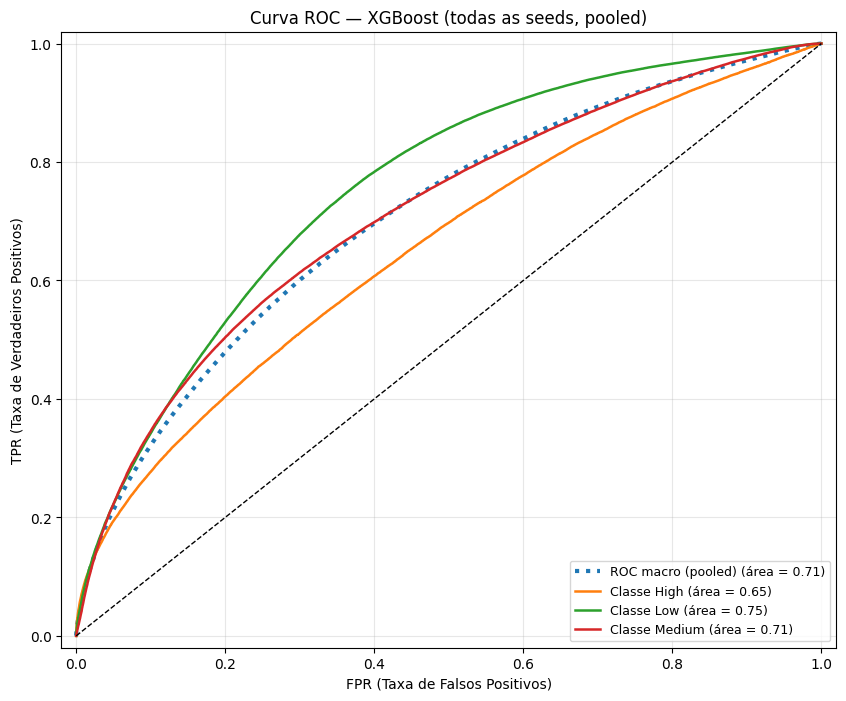

In [4]:
import joblib, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

xgb = joblib.load("xgb_results.pkl")
class_names = xgb["class_names"]
n_classes = len(class_names)

# 1) Concatena y_true e y_proba de todas as seeds
y_true_all, y_proba_all = [], []
for yt, yp in zip(xgb["all_y_true_list"], xgb["all_y_proba_list"]):
    if yp is None:
        continue
    y_true_all.append(np.asarray(yt))
    y_proba_all.append(np.asarray(yp))

y_true_all = np.concatenate(y_true_all, axis=0)
y_proba_all = np.concatenate(y_proba_all, axis=0)

# 2) Binariza
y_true_bin = label_binarize(y_true_all, classes=list(range(n_classes)))

# 3) ROC por classe
fpr, tpr, roc_auc = {}, {}, {}
valid_classes = []
for i in range(n_classes):
    y_i = y_true_bin[:, i]
    if (y_i.max() == 1) and (y_i.min() == 0):
        fpr[i], tpr[i], _ = roc_curve(y_i, y_proba_all[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        valid_classes.append(i)
    else:
        fpr[i], tpr[i], roc_auc[i] = np.array([0,1]), np.array([0,1]), np.nan

# 4) Macro pooled
if len(valid_classes) > 0:
    all_fpr = np.unique(np.concatenate([fpr[i] for i in valid_classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in valid_classes:
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(valid_classes)
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
else:
    fpr["macro"], tpr["macro"], roc_auc["macro"] = np.array([0,1]), np.array([0,1]), np.nan

# 5) Plot
plt.figure(figsize=(10, 8))

plt.plot(fpr["macro"], tpr["macro"],
         label=f'ROC macro (pooled) (área = {roc_auc["macro"]:.2f})',
         linestyle=':', linewidth=3)

for i in range(n_classes):
    if np.isnan(roc_auc[i]):
        continue
    plt.plot(fpr[i], tpr[i], lw=1.8, label=f'Classe {class_names[i]} (área = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([-0.02, 1.02]); plt.ylim([-0.02, 1.02])
plt.xlabel('FPR (Taxa de Falsos Positivos)')
plt.ylabel('TPR (Taxa de Verdadeiros Positivos)')
plt.title('Curva ROC — XGBoost (todas as seeds, pooled)')
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right", fontsize=9)
plt.show()


### Matriz de Confusão

#### Ajuda a interpretar onde o modelo está acertando ou errando na predição

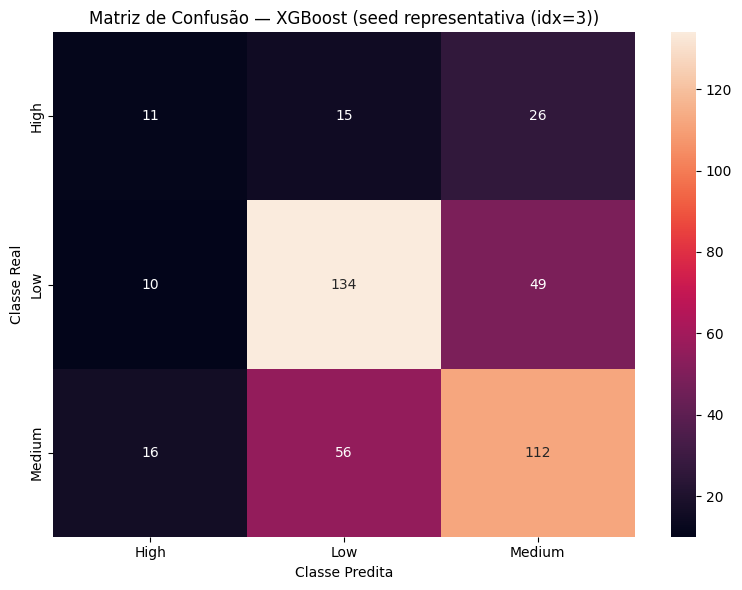

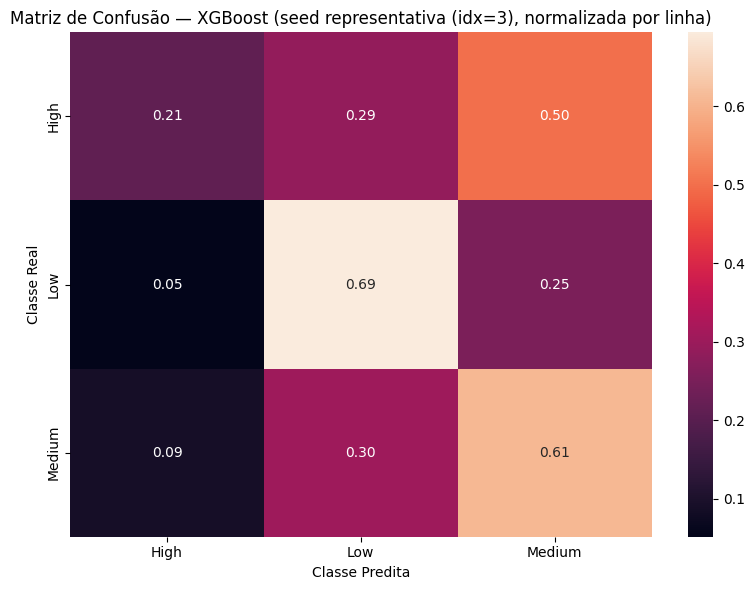

In [5]:
# ===== Matriz de Confusão — XGBoost (seed representativa OU pooled) =====
import joblib, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix

# 1) Carrega o PKL do XGBoost
xgb = joblib.load("xgb_results.pkl")
class_names = xgb["class_names"]
n_classes = len(class_names)

# 2) Escolha o modo
mode = "representativa"  # opções: "representativa" | "pooled"

if mode == "representativa":
    # Usa a execução mais próxima da acurácia média
    idx = xgb.get("best_idx", 0)
    y_true = np.asarray(xgb["all_y_true_list"][idx])
    y_pred = np.asarray(xgb["all_y_pred_list"][idx])
    title_suffix = f"seed representativa (idx={idx})"
elif mode == "pooled":
    # Concatena todos os testes das 1000 seeds
    y_true = np.concatenate([np.asarray(yt) for yt in xgb["all_y_true_list"] if yt is not None], axis=0)
    y_pred = np.concatenate([np.asarray(yp) for yp in xgb["all_y_pred_list"] if yp is not None], axis=0)
    title_suffix = "todas as seeds (pooled)"
else:
    raise ValueError("Defina mode como 'representativa' ou 'pooled'.")

# 3) Matriz de confusão (garantindo ordem das classes)
labels = list(range(n_classes))
cm = confusion_matrix(y_true, y_pred, labels=labels)

# 4) Normalização por linha com proteção (evita divisão por zero)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

# 5) Função de plot
def plot_confusion_matrix(cm_mat, classes, title):
    plt.figure(figsize=(8, 6))
    fmt = ".2f" if cm_mat.dtype.kind == "f" else "d"
    sns.heatmap(cm_mat, annot=True, fmt=fmt, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel("Classe Real")
    plt.xlabel("Classe Predita")
    plt.tight_layout()
    plt.show()

# 6) Plota normal e normalizada
plot_confusion_matrix(cm, class_names, f"Matriz de Confusão — XGBoost ({title_suffix})")
plot_confusion_matrix(cm_norm, class_names, f"Matriz de Confusão — XGBoost ({title_suffix}, normalizada por linha)")


### Precision-Recall Curve por classe

#### A curva Precision-Recall (PR) é uma ferramenta usada para avaliar o desempenho de classificadores, especialmente em problemas com classes desbalanceadas, como é o caso da predição de risco ESG.
#### A curva PR mostra a relação entre precision e recall à medida que o limiar de decisão do modelo é variado.

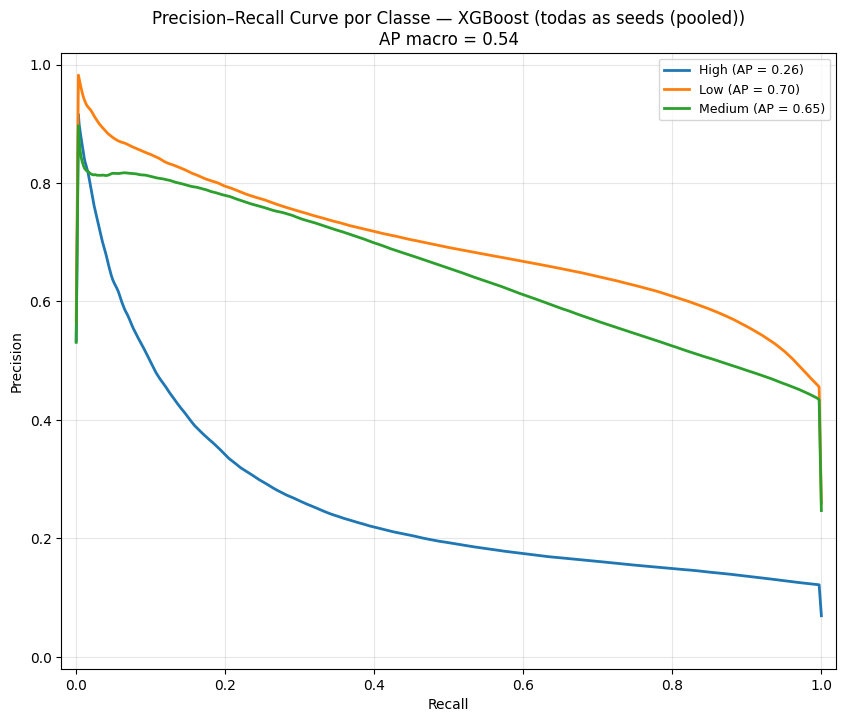

In [6]:
# ===== Precision–Recall Curve — XGBoost (curva fluida sem “platô 1.0”) =====
import joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# --- parâmetros ---
mode = "pooled"          # "representativa" | "pooled"
n_grid = 1000            # pontos na malha de recall (maior = mais fluido)
smooth_window = 7        # janela ímpar da média móvel; use 1 para desligar

def moving_avg(x, w):
    if w <= 1: 
        return x
    ker = np.ones(w, dtype=float) / w
    return np.convolve(x, ker, mode="same")

# 1) Carrega PKL
xgb = joblib.load("xgb_results.pkl")
class_names = xgb["class_names"]
n_classes = len(class_names)

# 2) Seleciona dados
if mode == "representativa":
    idx = xgb.get("best_idx", 0)
    y_true = np.asarray(xgb["all_y_true_list"][idx])
    y_proba = np.asarray(xgb["all_y_proba_list"][idx])
    title_suffix = f"seed representativa (idx={idx})"
elif mode == "pooled":
    y_true = np.concatenate([np.asarray(yt) for yt in xgb["all_y_true_list"] if yt is not None], axis=0)
    y_proba = np.concatenate([np.asarray(yp) for yp in xgb["all_y_proba_list"] if yp is not None], axis=0)
    title_suffix = "todas as seeds (pooled)"
else:
    raise ValueError("mode deve ser 'representativa' ou 'pooled'.")

if y_proba is None:
    raise RuntimeError("Probabilidades ausentes (predict_proba).")

# 3) Sanidade das probabilidades (opcional, ajuda a detectar erros de entrada)
if not np.allclose(y_proba.sum(axis=1), 1.0, atol=1e-3):
    print("⚠️ Aviso: linhas de y_proba não somam ≈ 1; verifique pré-processamento/modelo.")

# 4) Binariza rótulos para OvR
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

# 5) Calcula curvas PR por classe (sem envelope que distorce)
R_grid = np.linspace(0, 1, n_grid)
curves, ap_per_class, valid_classes = {}, {}, []

for i in range(n_classes):
    y_i = y_true_bin[:, i]
    if (y_i.max() == 1) and (y_i.min() == 0):
        P, R, _ = precision_recall_curve(y_i, y_proba[:, i])  # R já é não-decrescente

        # (a) remover duplicatas de recall mantendo a MAIOR precisão (suaviza sem “colar” em 1)
        df = pd.DataFrame({"R": R, "P": P})
        df = df.groupby("R", as_index=False)["P"].max().sort_values("R")
        R_u = df["R"].to_numpy()
        P_u = df["P"].to_numpy()

        # (b) interpolar em grade fina
        P_itp = np.interp(R_grid, R_u, P_u)

        # (c) média móvel curta (opcional) — NÃO força monotonicidade
        P_smooth = moving_avg(P_itp, smooth_window)

        curves[i] = (R_grid, P_smooth)
        ap_per_class[i] = float(average_precision_score(y_i, y_proba[:, i]))
        valid_classes.append(i)
    else:
        curves[i] = (None, None)
        ap_per_class[i] = np.nan

# 6) AP macro
ap_macro = float(np.nanmean([ap_per_class[i] for i in valid_classes])) if valid_classes else np.nan

# 7) Plot
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    R, P = curves[i]
    if R is None:
        continue
    plt.plot(R, P, lw=2, label=f"{class_names[i]} (AP = {ap_per_class[i]:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve por Classe — XGBoost ({title_suffix})\nAP macro = {ap_macro:.2f}")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right", fontsize=9)
plt.xlim([-0.02, 1.02]); plt.ylim([-0.02, 1.02])
plt.show()


### Vendo importância das features

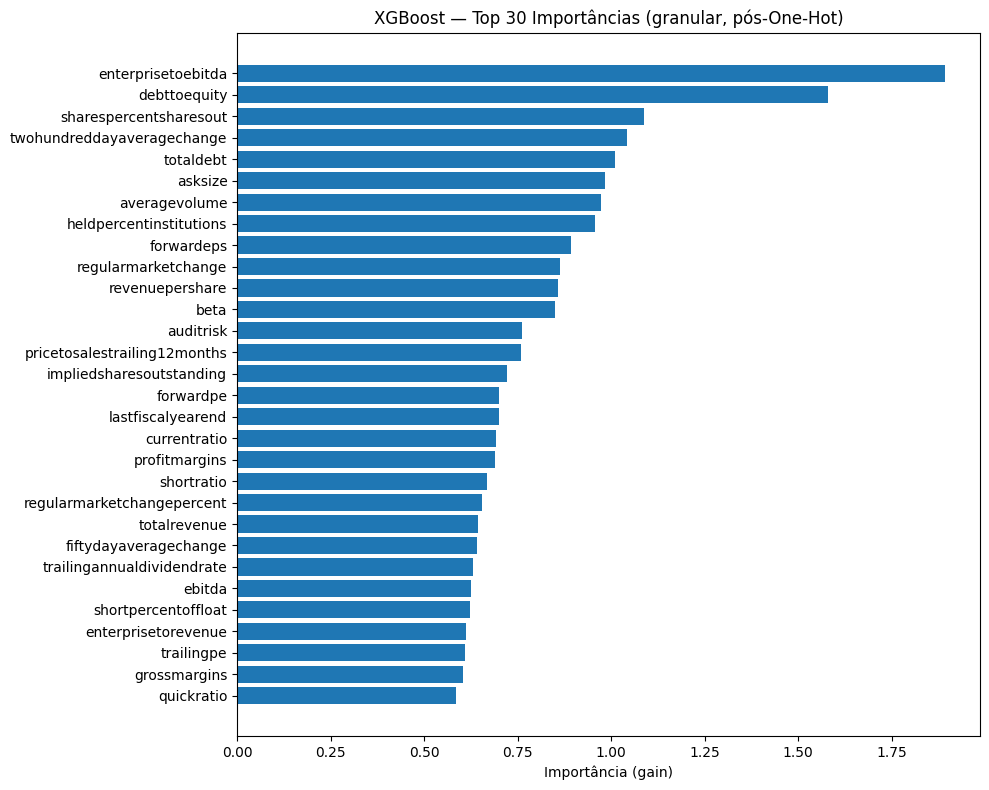

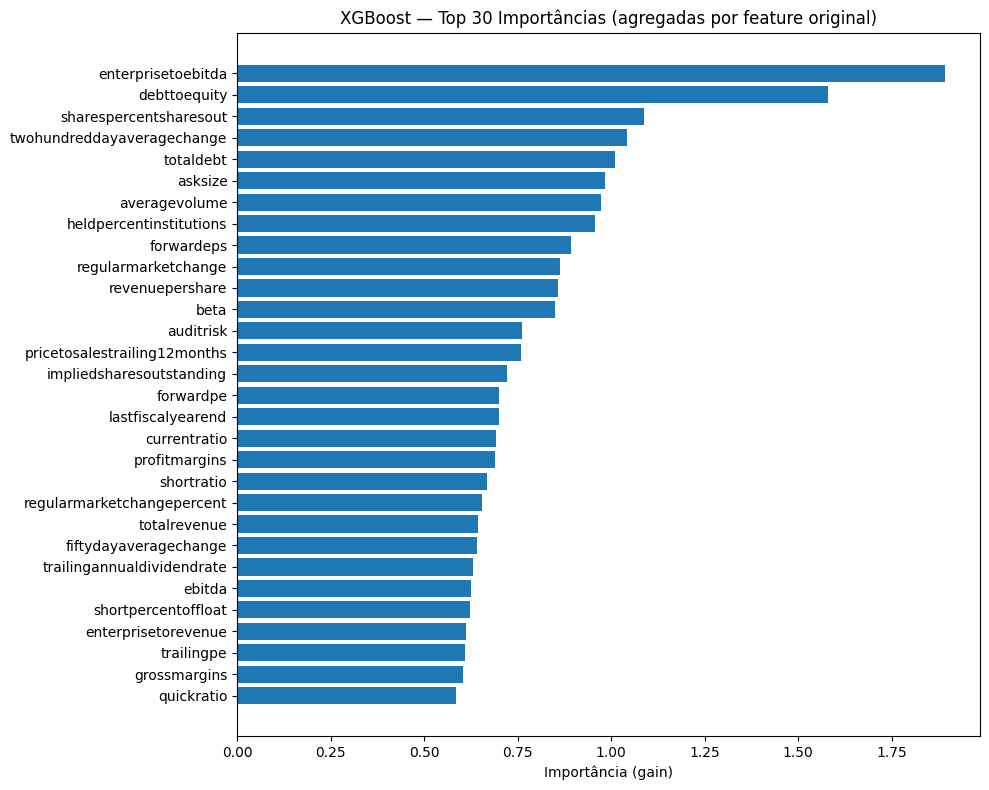

In [7]:
# ===== XGBoost Feature Importance (robusto a versões do sklearn) =====
import joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import clone

# --- Configs ---
pkl_path = "xgb_results.pkl"
importance_type = "gain"   # "gain" | "weight" | "cover" | "total_gain" | "total_cover"
topn = 30

# 1) Pega o pipeline treinado (clf) e X
d = joblib.load(pkl_path)
pipe = d["clf"]                 # Pipeline([('prep', ...), ('clf', XGBClassifier(...))])
prep: ColumnTransformer = pipe.named_steps["prep"]
xgb = pipe.named_steps.get("clf", None)
X = d["X"]                      # DataFrame original (colunas antes do OHE)

if xgb is None:
    raise RuntimeError("Não encontrei o passo 'clf' no pipeline salvo.")

# 2) Função robusta para extrair nomes transformados do ColumnTransformer
def get_ct_feature_names_robust(prep: ColumnTransformer, X_df: pd.DataFrame) -> np.ndarray:
    # a) Tenta a API moderna
    try:
        names = prep.get_feature_names_out()
        # ColumnTransformer costuma prefixar com o nome do transformador; vamos limpar opcionalmente
        return np.asarray([n.split("__", 1)[-1] if "__" in n else n for n in names], dtype=str)
    except Exception:
        pass

    names_out = []
    # Usa transformadores "fitted" se existirem; senão, os declarados
    transformers = getattr(prep, "transformers_", None) or prep.transformers
    for name, trans, cols in transformers:
        if name == "remainder":
            continue

        # Se for um Pipeline (numérico ou categórico)
        if hasattr(trans, "named_steps"):
            # tenta achar um OneHotEncoder dentro do pipeline
            ohe = None
            for step_name, step in trans.named_steps.items():
                if isinstance(step, OneHotEncoder):
                    ohe = step
                    break

            if ohe is not None:
                # tenta usar categorias_ do OHE fitted
                try:
                    cats_list = ohe.categories_
                except AttributeError:
                    # O OHE não estava fitted (raro, mas possível em certas versões/situações):
                    # fitamos UMA CÓPIA em X[cols] só para descobrir os nomes — não altera seu pipeline treinado.
                    ohe_copy = clone(ohe)
                    ohe_copy.fit(X_df[cols])
                    cats_list = ohe_copy.categories_

                for col, cats in zip(cols, cats_list):
                    names_out.extend([f"{col}__{str(c)}" for c in cats])
            else:
                # pipeline numérico (imputer etc.): nomes são as próprias cols
                names_out.extend(list(cols))
        else:
            # Transformador direto (raro aqui): usa cols
            names_out.extend(list(cols))
    return np.asarray(names_out, dtype=str)

feat_names_trans = get_ct_feature_names_robust(prep, X)

# 3) Importância no XGBoost
bst = xgb.get_booster()
sc = bst.get_score(importance_type=importance_type)  # dict: {"f0": val, "f1": val, ...}

# Ordem interna de features no booster
fn_internal = bst.feature_names
if not fn_internal:
    # fallback: "f0"... até o número de colunas transformadas
    fn_internal = [f"f{i}" for i in range(len(feat_names_trans))]

# Vetor de importâncias na ordem das features internas
imp_vec = np.array([sc.get(f, 0.0) for f in fn_internal], dtype=float)

# Sanidade: alinhar comprimentos se necessário
if len(imp_vec) != len(feat_names_trans):
    n = min(len(imp_vec), len(feat_names_trans))
    print(f"[Aviso] Tamanhos divergentes: imp_vec={len(imp_vec)} vs feat_names={len(feat_names_trans)}. "
          f"Alinhando para {n}.")
    imp_vec = imp_vec[:n]
    feat_names_trans = feat_names_trans[:n]

# 4) DataFrame granular (pós-OHE)
df_imp_granular = pd.DataFrame({"feature_trans": feat_names_trans, "importance": imp_vec})
df_imp_granular.sort_values("importance", ascending=False, inplace=True)

# 5) Agregação por feature original (somando dummies OHE)
def original_name(trans_name: str) -> str:
    return trans_name.split("__", 1)[0] if "__" in trans_name else trans_name

df_imp_granular["feature_orig"] = df_imp_granular["feature_trans"].map(original_name)
df_imp_agg = (df_imp_granular
              .groupby("feature_orig", as_index=False)["importance"]
              .sum()
              .sort_values("importance", ascending=False))

# 6) Plots
def plot_top(df, feat_col, val_col, title, topn=30):
    top = df.head(topn).iloc[::-1]  # invertido para barh "do maior no topo"
    plt.figure(figsize=(10, 8))
    plt.barh(top[feat_col], top[val_col])
    plt.xlabel("Importância" + (f" ({importance_type})" if importance_type else ""))
    plt.title(title)
    plt.tight_layout()
    plt.show()

# (A) Top-N granular (cada dummy OHE aparece separadamente)
plot_top(df_imp_granular, "feature_trans", "importance",
         f"XGBoost — Top {topn} Importâncias (granular, pós-One-Hot)", topn=topn)

# (B) Top-N agregada por feature original (soma dos dummies OHE)
plot_top(df_imp_agg, "feature_orig", "importance",
         f"XGBoost — Top {topn} Importâncias (agregadas por feature original)", topn=topn)

# 7) (Opcional) Exportar tabelas
# df_imp_granular.to_csv("xgb_feature_importance_granular.csv", index=False)
# df_imp_agg.to_csv("xgb_feature_importance_aggregated.csv", index=False)


## 📊 Top 30 Features Mais Importantes — XGBoost (agregado por feature original)

| **Feature**                  | **Significado / Interpretação**                             | **Relevância para ESG**                                                                 |
|-------------------------------|-------------------------------------------------------------|-----------------------------------------------------------------------------------------|
| `beta`                        | Sensibilidade do papel ao mercado (risco sistemático).      | Empresas com beta alto tendem a ser mais vulneráveis a riscos regulatórios e climáticos. |
| `forwardeps`                  | Lucro por ação projetado (forward EPS).                    | Reflete expectativas de resultados futuros; riscos ESG materiais podem afetar projeções. |
| `bid`                         | Profundidade da ordem de compra.                           | Maior liquidez favorece disciplina de mercado e reação rápida a eventos ESG.             |
| `grossmargins`                | Margem bruta.                                              | Eficiência operacional; empresas mais eficientes têm espaço para práticas sustentáveis.  |
| `totalrevenue`                | Receita total.                                             | Expansão de receitas pode sinalizar escala sustentável ou riscos sociais/ambientais.     |
| `ebitdamargins`               | Margens EBITDA.                                            | Resiliência operacional e capacidade de financiar transições ESG.                        |
| `trailingpe`                  | Preço/Lucro histórico (trailing P/E).                      | Indica percepção de mercado, influenciada por riscos regulatórios e reputacionais ESG.   |
| `enterprisetoebitda`          | EV/EBITDA (valuation relativo).                            | Governança e riscos ambientais afetam múltiplos de valuation.                            |
| `volume`                      | Volume negociado.                                          | Alta liquidez favorece monitoramento e reações rápidas a eventos ESG.                    |
| `averagevolume10days`         | Volume médio de 10 dias.                                   | Captura interesse de investidores, inclusive após divulgações ESG.                       |
| `fiftytwoweekhighchange`      | Variação relativa ao preço máximo em 52 semanas.           | Indica reprecificação após choques reputacionais ou regulatórios ESG.                    |
| `epscurrentyear`              | Lucro por ação esperado para o ano corrente.               | Expectativas de curto prazo afetadas por litígios ou regulações ESG.                     |
| `sharesshortpriormonth`       | Percentual de ações vendidas a descoberto (mês anterior).  | Short elevado pode refletir percepção de riscos sociais, ambientais ou de governança.    |
| `forwardpe`                   | Preço/Lucro projetado.                                     | Reflete expectativas de mercado futuras; riscos ESG podem pressionar valuation.          |
| `fiftydayaveragechangepercent`| Variação em relação à média móvel de 50 dias (%).          | Captura efeitos de notícias recentes, incluindo incidentes ESG.                          |
| `regularmarketchangepercent`  | Variação percentual diária no preço.                       | Sensível a controvérsias ESG e a divulgações de sustentabilidade.                        |
| `priceepscurrentyear`         | Preço/Lucro estimado para o ano corrente.                 | Expectativas de curto prazo, vulneráveis a impactos ESG materiais.                       |
| `impliedsharesoutstanding`    | Ações em circulação implícitas.                           | Relaciona-se à liquidez e governança do capital.                                         |
| `operatingmargins`            | Margens operacionais.                                      | Empresas com margens elevadas conseguem absorver custos ESG.                             |
| `fiftytwoweeklow`             | Preço mínimo em 52 semanas.                               | Reflete percepção negativa persistente após controvérsias ESG.                           |
| `enterpriserevenue`           | Receita corporativa consolidada.                          | Pode capturar escala e capacidade de investir em sustentabilidade.                       |
| `heldpercentinstitutions`     | % de ações detidas por institucionais.                     | Pressão por maior disclosure e governança ESG sólida.                                    |
| `pricetosalestrailing12months`| Relação Preço/Vendas últimos 12 meses.                     | Avaliação de mercado sensível a mudanças estruturais ESG.                                |
| `heldpercentinsiders`         | % de ações detidas por insiders.                          | Alta concentração pode sinalizar riscos de governança.                                   |
| `profitmargins`               | Margem líquida.                                            | Sustentabilidade de lucros, permitindo investimentos em ESG.                             |
| `boardrisk`                   | Indicador de risco de governança do conselho.              | Diretamente ligado ao pilar **G**; falhas aumentam riscos de supervisão.                 |
| `regularmarketchange`         | Variação absoluta do preço.                               | Relacionada à volatilidade provocada por eventos ESG.                                    |
| `trailingannualdividendrate`  | Valor anual de dividendos pagos.                          | Disciplina financeira; estabilidade de dividendos sugere governança sólida.              |
| `dividendyield`               | Dividend Yield atual.                                     | Indicador de estabilidade financeira e disciplina de capital.                            |
| `overallrisk`                 | Escore agregado de risco.                                 | Síntese de exposição global, incluindo governança, mercado e sustentabilidade.           |



### Aplicando SHAP (Shapley Additive explanations) por classificação para interpretar as decisões do modelo 

#### SHAP (SHapley Additive exPlanations) é uma técnica de interpretação de modelos baseada na teoria dos jogos de Shapley. Ele atribui a cada feature uma contribuição quantitativa para a previsão de um determinado exemplo, permitindo entender:

#### -Quais variáveis mais influenciaram o modelo.

#### -Em que direção elas atuaram (aumentaram ou diminuíram a chance de determinada classe).

#### -Quão sensível o modelo é às variações dessas variáveis.

shape SHAP final: (143, 97, 3) | classes: ['High', 'Low', 'Medium']


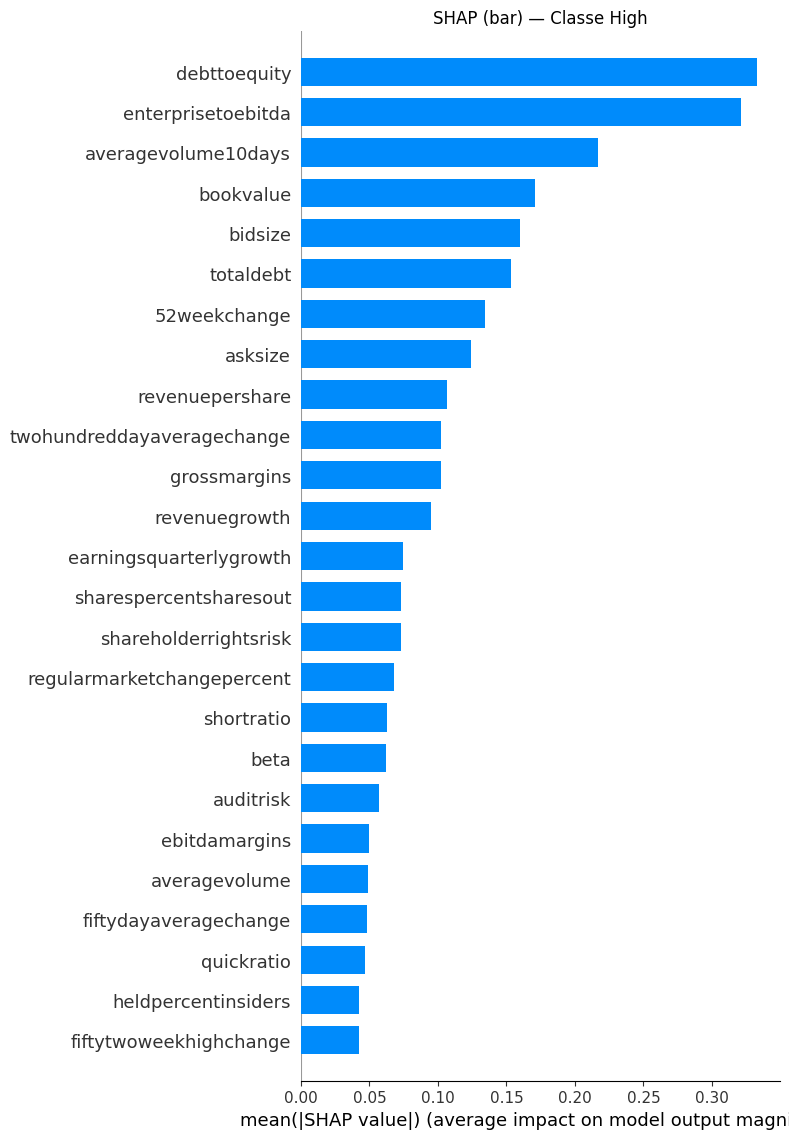

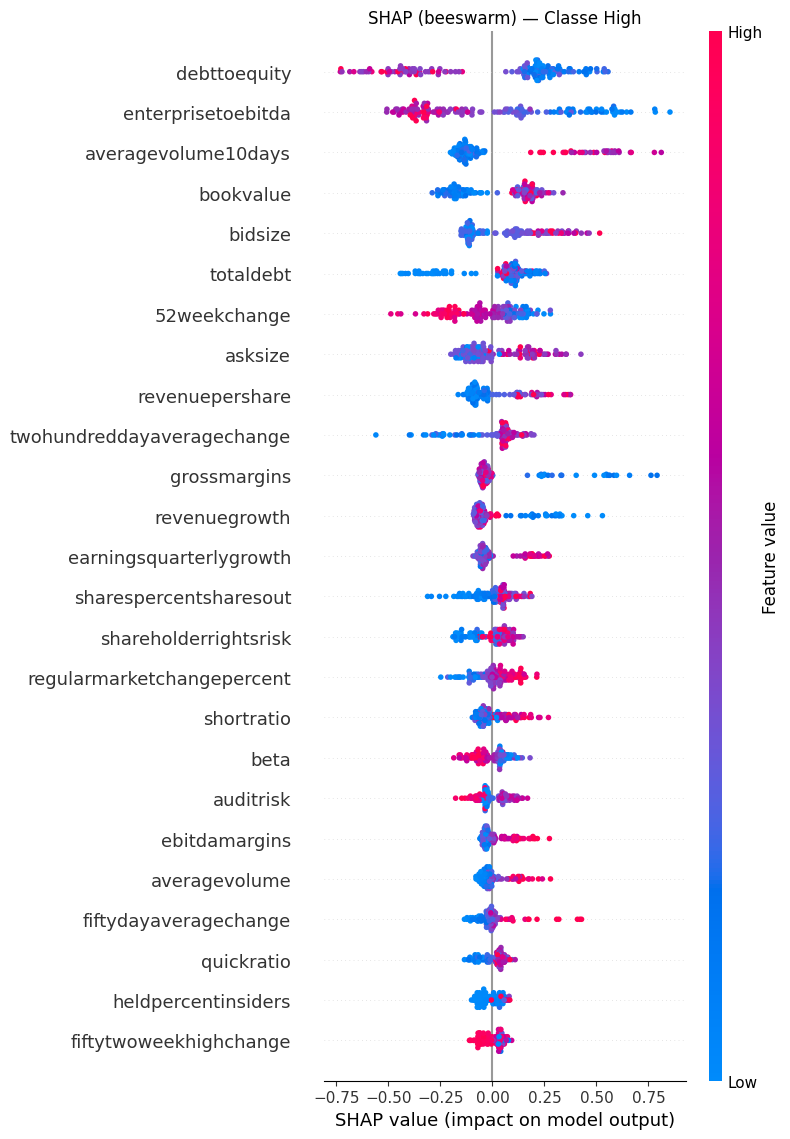

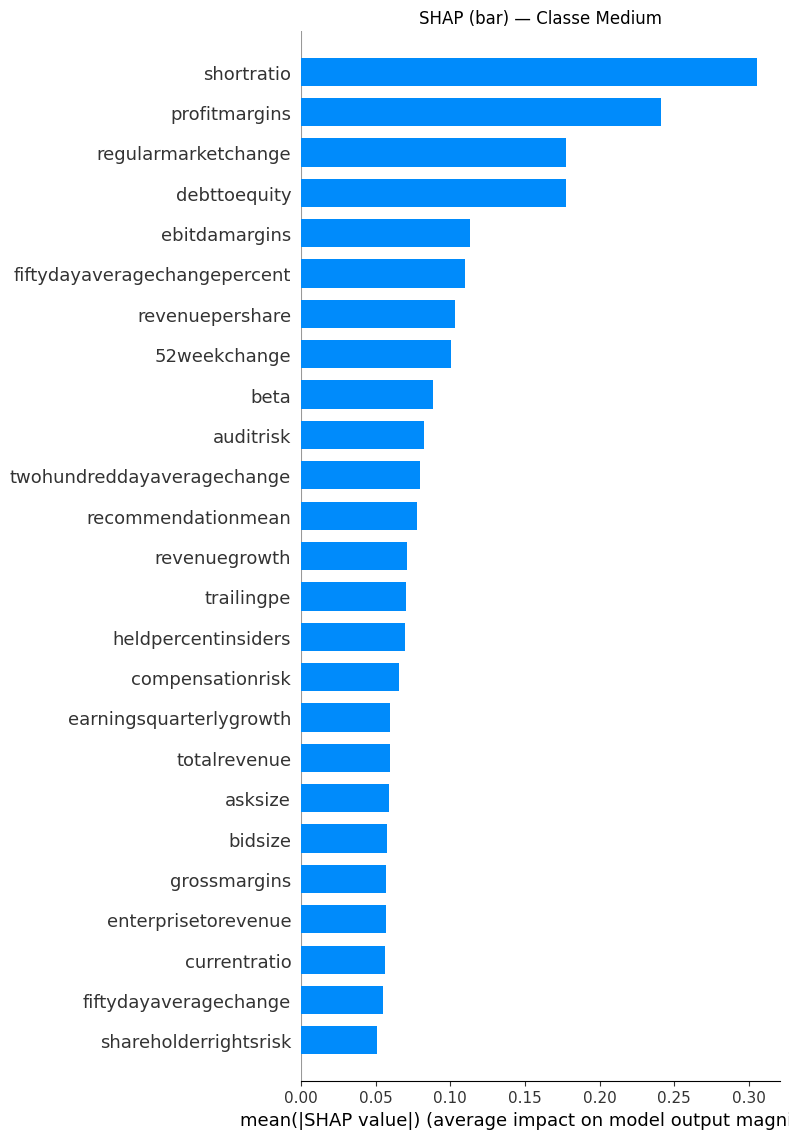

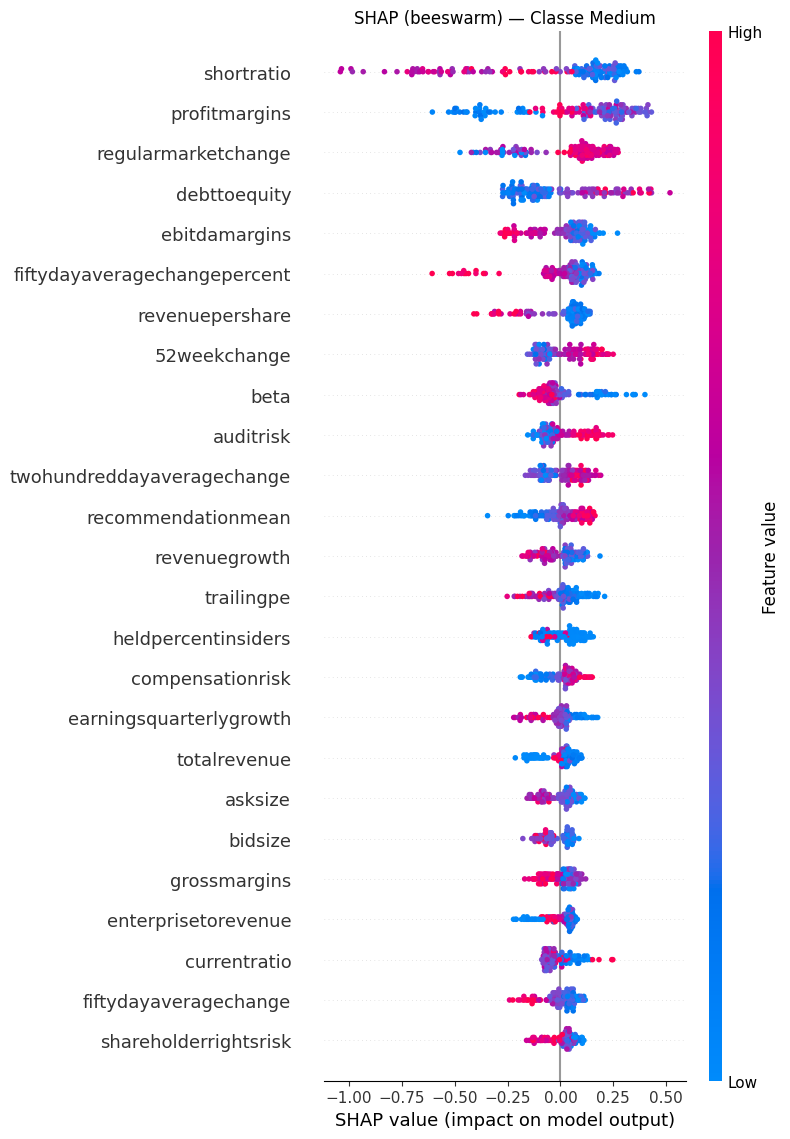

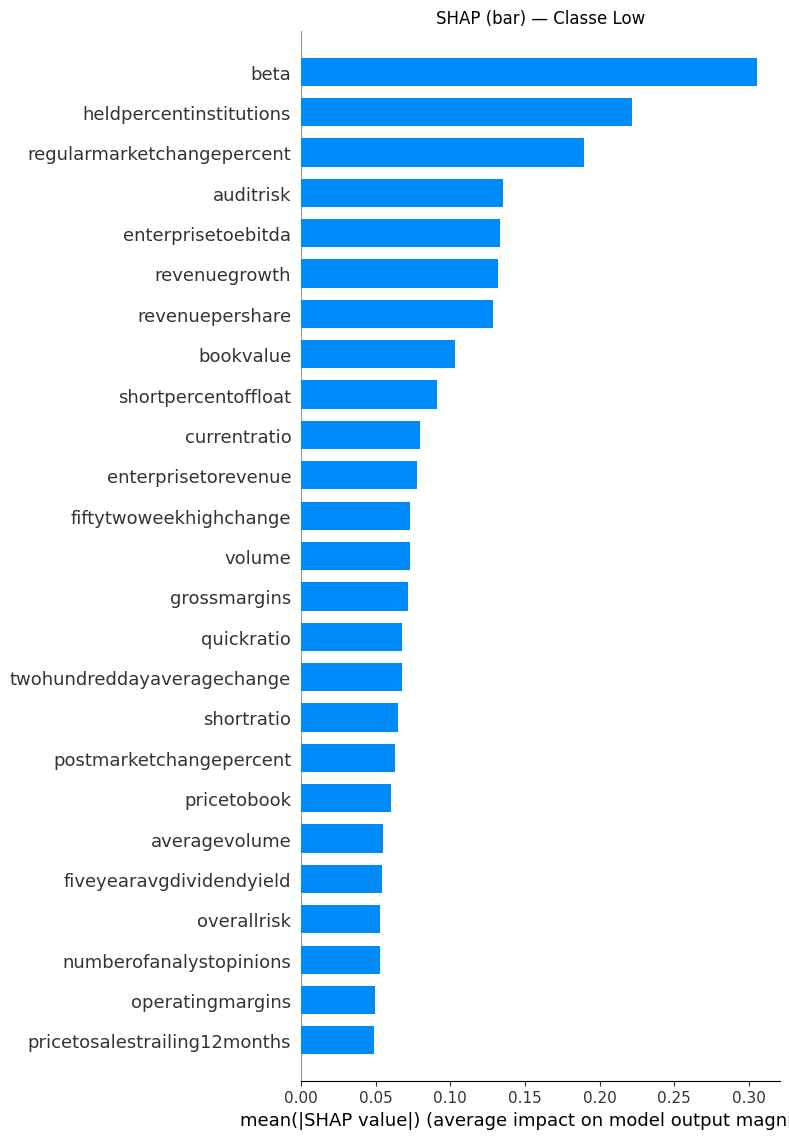

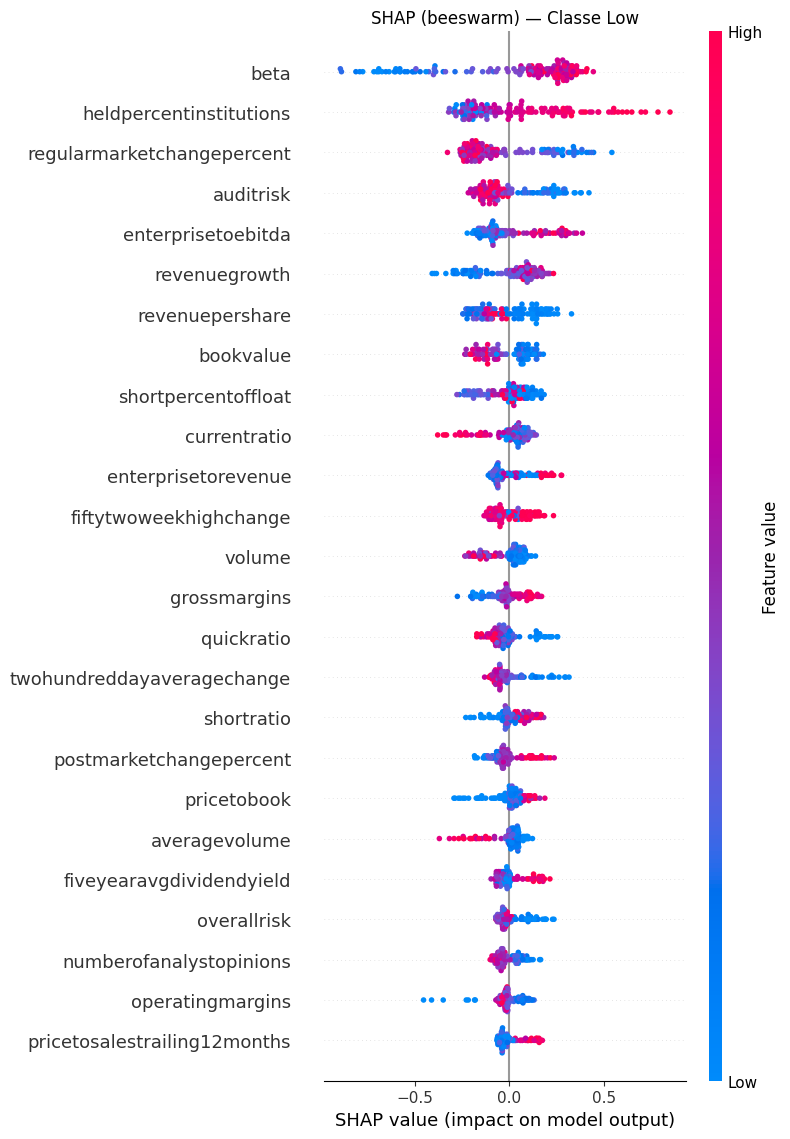

In [8]:
# ===== SHAP para XGBoost (robusto p/ formato novo do PKL e multiclasses) =====
import joblib, numpy as np, pandas as pd, scipy.sparse as sp
import shap, matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

# ------------ Configs ------------
pkl_path = "xgb_results.pkl"
max_display = 25          # nº de features no gráfico
background_max = 200      # tamanho do background SHAP

# ---------- 0) Carrega PKL ----------
d = joblib.load(pkl_path)
pipe = d["clf"]                               # imblearn.Pipeline: prep -> smote -> clf
prep: ColumnTransformer = pipe.named_steps["prep"]
xgb = pipe.named_steps["clf"]
X_full: pd.DataFrame = d["X"]
y_enc = d["y_encoded"]
class_names = d["class_names"]
seed_list = d.get("seed_list", None)
best_idx = d.get("best_idx", 0)
split_ranges = d.get("split_ranges", None)

# ---------- util: nomes pós-ColumnTransformer (robusto) ----------
from sklearn.base import clone as sk_clone

def get_ct_feature_names_robust(prep: ColumnTransformer, X_df: pd.DataFrame) -> np.ndarray:
    try:
        names = prep.get_feature_names_out()
        return np.asarray([n.split("__", 1)[-1] if "__" in n else n for n in names], dtype=str)
    except Exception:
        pass

    names_out = []
    transformers = getattr(prep, "transformers_", None) or prep.transformers
    for name, trans, cols in transformers:
        if name == "remainder":
            continue
        if hasattr(trans, "named_steps"):
            ohe = None
            for step_name, step in trans.named_steps.items():
                if isinstance(step, OneHotEncoder):
                    ohe = step; break
            if ohe is not None:
                try:
                    cats_list = ohe.categories_
                except AttributeError:
                    ohe_copy = sk_clone(ohe)
                    ohe_copy.fit(X_df[cols])
                    cats_list = ohe_copy.categories_
                for col, cats in zip(cols, cats_list):
                    names_out.extend([f"{col}__{str(c)}" for c in cats])
            else:
                names_out.extend(list(cols))
        else:
            names_out.extend(list(cols))
    return np.asarray(names_out, dtype=str)

# ---------- 1) Determina um split de teste representativo ----------
# Caso 1: split_ranges com dicts (formato antigo) -> usa diretamente
use_saved_indices = False
train_idx = None; test_idx = None
if split_ranges and isinstance(split_ranges[0], dict) and \
   ("train_idx" in split_ranges[best_idx]) and ("test_idx" in split_ranges[best_idx]):
    tr = split_ranges[best_idx]["train_idx"]
    te = split_ranges[best_idx]["test_idx"]
    train_idx = np.array(tr, dtype=int); test_idx = np.array(te, dtype=int)
    use_saved_indices = True

# Caso 2: formato novo (tuplas). Reconstrói os índices via StratifiedKFold e a seed representativa
if not use_saved_indices:
    # escolhe uma seed representativa
    if seed_list and len(seed_list) > 0:
        seed = seed_list[best_idx if best_idx < len(seed_list) else 0]
    else:
        seed = 42
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
    # pega o PRIMEIRO fold como teste (poderia iterar/agregar também)
    for tr_idx, te_idx in skf.split(X_full, y_enc):
        train_idx = np.array(tr_idx, dtype=int)
        test_idx  = np.array(te_idx, dtype=int)
        break

X_train_raw = X_full.iloc[train_idx].copy()
X_test_raw  = X_full.iloc[test_idx].copy()

# ---------- 2) Transforma com o mesmo prep do pipeline ----------
X_train_tr = prep.transform(X_train_raw)
X_test_tr  = prep.transform(X_test_raw)
if sp.issparse(X_train_tr): X_train_tr = X_train_tr.toarray()
if sp.issparse(X_test_tr):  X_test_tr  = X_test_tr.toarray()

feat_names = get_ct_feature_names_robust(prep, X_full)
n = min(len(feat_names), X_test_tr.shape[1])
feat_names = feat_names[:n]
X_train_tr = X_train_tr[:, :n]
X_test_tr  = X_test_tr[:,  :n]
X_shap = pd.DataFrame(X_test_tr, columns=feat_names)

# ---------- 3) Explainer SHAP (com fallback) ----------
bg_n = min(background_max, X_train_tr.shape[0])
background = X_train_tr[:bg_n, :]

# Tenta o wrapper genérico (que usa TreeExplainer para XGB)
explainer = shap.Explainer(xgb, background)
sv = explainer(X_test_tr, check_additivity=False)

vals = getattr(sv, "values", sv)
need_fallback = False
if vals is None:
    need_fallback = True
else:
    # multiclasses esperado (N,F,C); se vier 2D ou near-zero, cai no fallback
    if vals.ndim == 2 or np.allclose(np.nanstd(vals), 0.0):
        need_fallback = True

if need_fallback:
    print("ℹ️  Fallback: TreeExplainer direto no Booster (model_output='raw').")
    booster = xgb.get_booster()
    expl_fb = shap.TreeExplainer(booster, data=background, feature_perturbation="interventional")
    shap_vals_list = expl_fb.shap_values(X_test_tr, check_additivity=False)
    if isinstance(shap_vals_list, list):
        vals = np.stack([np.asarray(a) for a in shap_vals_list], axis=-1)  # (N,F,C)
    else:
        vals = shap_vals_list[..., None]  # binário -> (N,F,1)

print("shape SHAP final:", vals.shape, "| classes:", class_names)

# ---------- 4) Índices de classes ----------
cls_to_idx = {c: i for i, c in enumerate(class_names)}
idx_high   = cls_to_idx.get("High")
idx_medium = cls_to_idx.get("Medium")
idx_low    = cls_to_idx.get("Low")

# ---------- 5) Função de plot por classe ----------
def plot_class(vals_3d, X_df, label, idx, max_display=25):
    if idx is None:
        print(f"Aviso: classe '{label}' não encontrada em {class_names}")
        return
    v = vals_3d[:, :, idx]
    if np.allclose(np.nanstd(v), 0.0):
        print(f"⚠️  SHAP ~ nulo para classe '{label}' (scores muito colados ao baseline).")
    shap.summary_plot(v, X_df, plot_type="bar", max_display=max_display, show=False)
    plt.title(f"SHAP (bar) — Classe {label}")
    plt.tight_layout(); plt.show()

    shap.summary_plot(v, X_df, max_display=max_display, show=False)
    plt.title(f"SHAP (beeswarm) — Classe {label}")
    plt.tight_layout(); plt.show()

# ---------- 6) Plota por classe ----------
plot_class(vals, X_shap, "High",   idx_high,   max_display=max_display)
plot_class(vals, X_shap, "Medium", idx_medium, max_display=max_display)
plot_class(vals, X_shap, "Low",    idx_low,    max_display=max_display)


### Calculando métricas por setor e matriz de confusão

,support,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
financial-services,63000,0.586095,0.411110,0.384814,0.392512,0.602638,0.586095,0.587451
technology,63000,0.737127,0.375514,0.379239,0.376683,0.759650,0.737127,0.747888
industrials,58000,0.420103,0.341133,0.374697,0.326170,0.390397,0.420103,0.374496
healthcare,53000,0.629358,0.451365,0.441393,0.442860,0.661324,0.629358,0.643533
consumer-cyclical,51000,0.574275,0.408180,0.384735,0.395699,0.604643,0.574275,0.588477
consumer-defensive,33000,0.594667,0.483182,0.465794,0.469353,0.617631,0.594667,0.603562
real-estate,28000,0.906821,0.320703,0.313469,0.317045,0.927747,0.906821,0.917165
utilities,28000,0.692321,0.324531,0.324802,0.314135,0.627484,0.692321,0.650816
basic-materials,19000,0.351368,0.360899,0.389258,0.315295,0.468710,0.351368,0.376984
energy,19000,0.473684,0.352541,0.335536,0.312045,0.659872,0.473684,0.524553


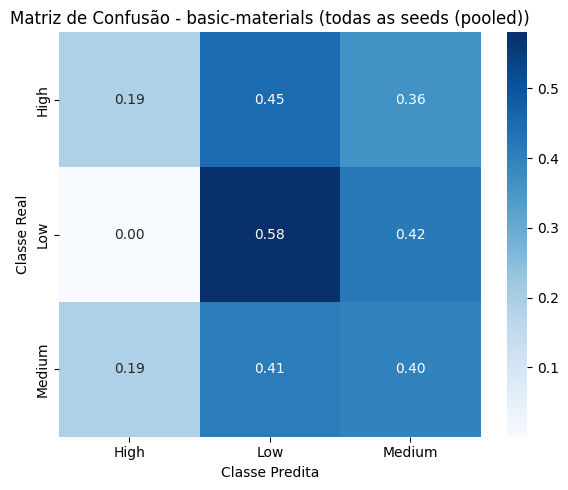

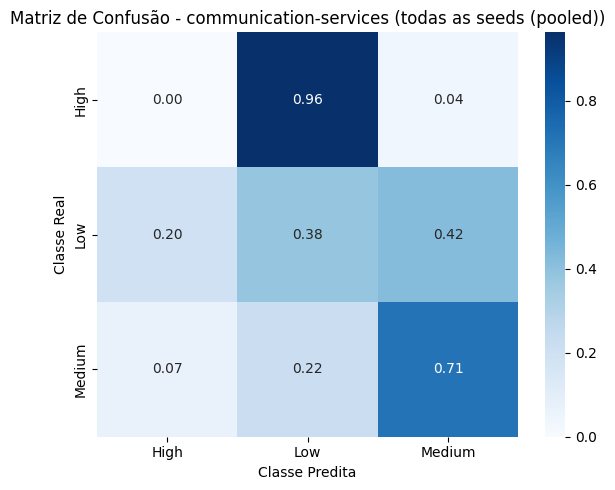

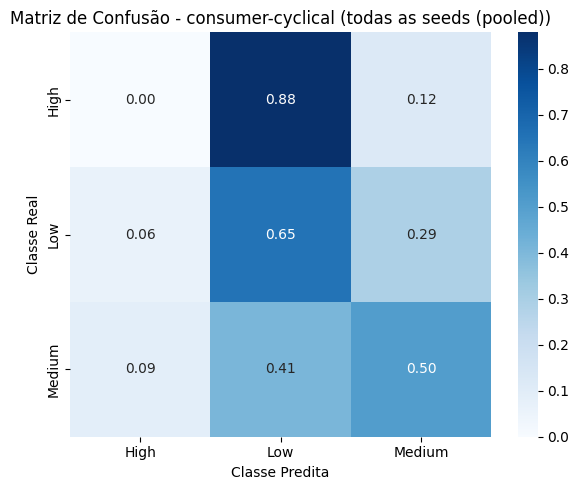

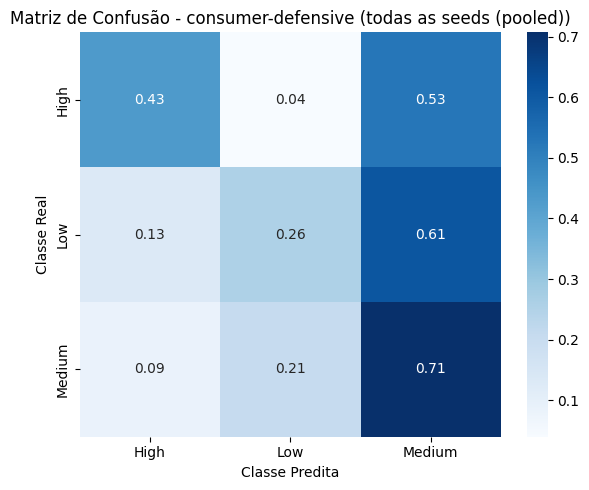

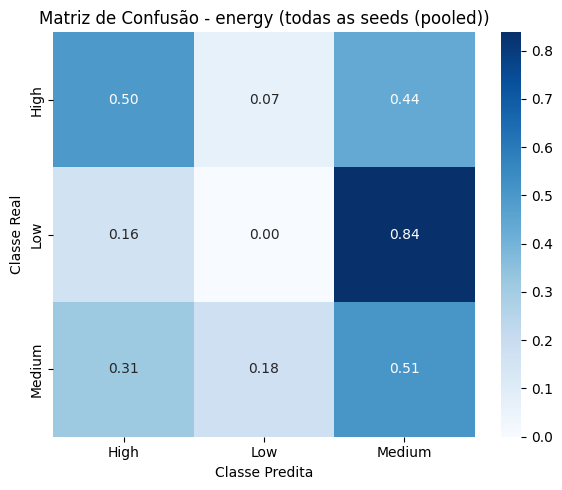

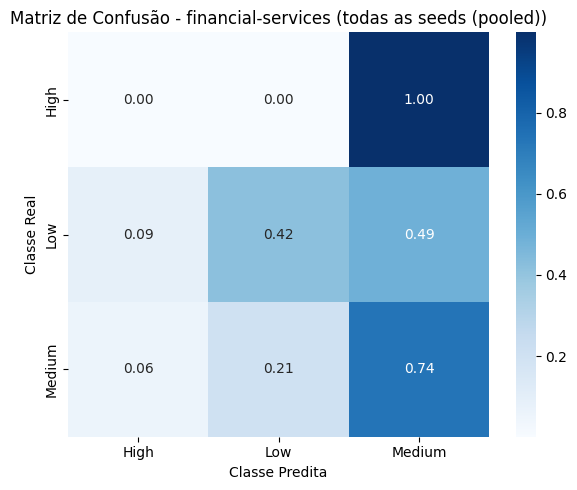

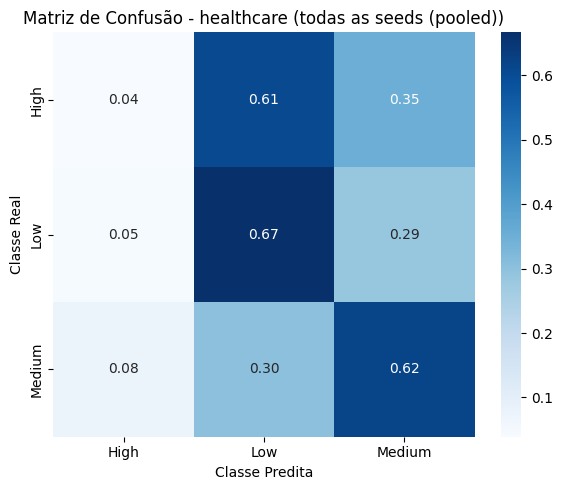

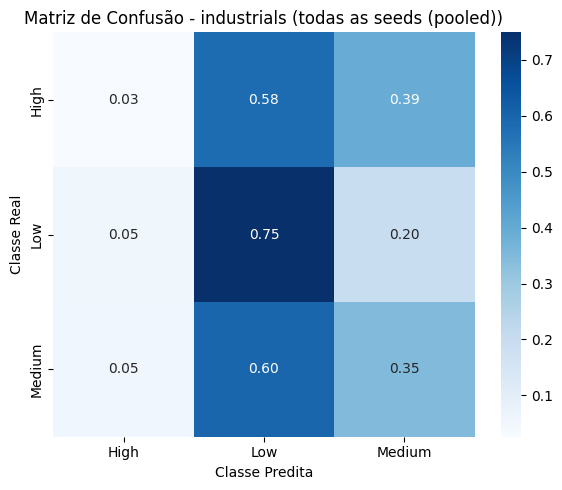

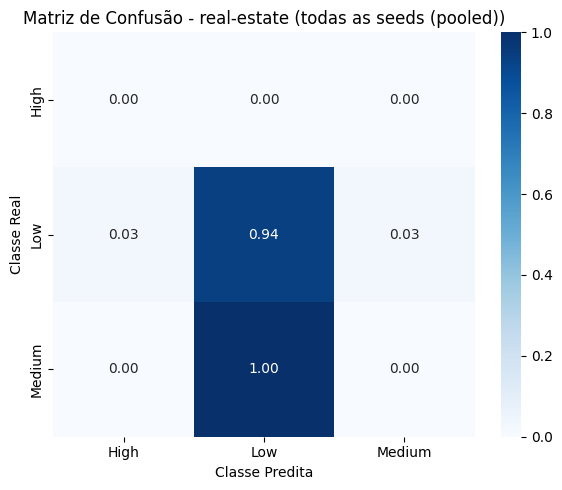

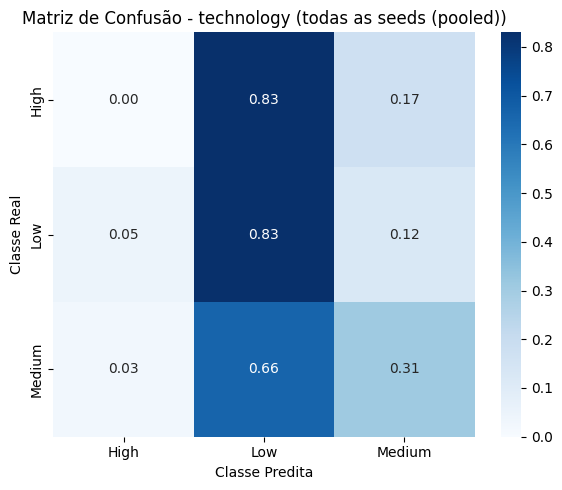

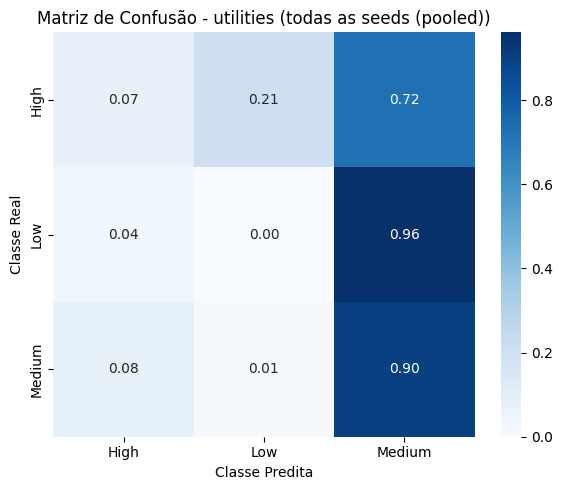

In [9]:
# === MÉTRICAS POR SETOR — XGBoost (inline) ===
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Carrega PKL (precisa ter all_tickers_test populado)
d = joblib.load("xgb_results.pkl")
class_names = d["class_names"]
le = d.get("le", None)

# 1) Escolha o modo: "pooled" (todas as seeds) ou "representativa" (best_idx)
MODE = "pooled"  # ou "representativa"

if MODE == "representativa":
    i = int(d.get("best_idx", 0))
    y_true  = np.asarray(d["all_y_true_list"][i])
    y_pred  = np.asarray(d["all_y_pred_list"][i])
    tickers = np.asarray(d["all_tickers_test"][i], dtype=str)
    title_suffix = f"seed representativa (idx={i})"
elif MODE == "pooled":
    y_true  = np.concatenate([np.asarray(v) for v in d["all_y_true_list"] if v is not None])
    y_pred  = np.concatenate([np.asarray(v) for v in d["all_y_pred_list"] if v is not None])
    tickers = np.concatenate([np.asarray(v, dtype=str) for v in d["all_tickers_test"] if v is not None])
    title_suffix = "todas as seeds (pooled)"
else:
    raise ValueError("MODE deve ser 'representativa' ou 'pooled'.")

# 2) df_resultados
df_resultados = pd.DataFrame({
    "ticker": pd.Series(tickers, dtype=str).str.upper(),
    "y_true": y_true,
    "y_pred": y_pred
})
# (opcional) rótulos textuais para depuração
try:
    df_resultados["y_true_label"] = le.inverse_transform(df_resultados["y_true"])
    df_resultados["y_pred_label"] = le.inverse_transform(df_resultados["y_pred"])
except Exception:
    pass

# 3) Detecta colunas de ticker e setor em df_filtrado (ou ajuste manualmente)
assert 'df_filtrado' in globals(), "Esperado 'df_filtrado' no escopo para puxar o setor."
def _guess_ticker_col(df):
    prefs = ["ticker","TICKER","symbol","SYMBOL","Ticker","Symbol"]
    low = {c.lower(): c for c in df.columns}
    for p in prefs:
        if p.lower() in low: return low[p.lower()]
    for c in df.columns:
        cl = c.lower()
        if any(k in cl for k in ["ticker","symbol","codigo","asset","sigla"]):
            return c
    return None

def _guess_sector_col(df):
    keys = ["sectorkey","sector","sectordisp","industry","industrykey","industrydisp"]
    low = {c.lower(): c for c in df.columns}
    for k in keys:
        if k in low and df[low[k]].nunique(dropna=True) <= 200:
            return low[k]
    return None

tcol = _guess_ticker_col(df_filtrado) or "ticker"
scol = _guess_sector_col(df_filtrado) or "sectorkey"

base = df_filtrado[[tcol, scol]].copy()
base.columns = ["ticker", "sectorkey"]
base["ticker"] = base["ticker"].astype(str).str.upper()

# 4) Merge e métricas por setor
df_sector = pd.merge(df_resultados, base, on="ticker", how="left")

sector_reports = {}
for sector, g in df_sector.groupby("sectorkey"):
    if g["y_true"].nunique() < 2:
        continue  # evita erro quando há somente uma classe
    rep = classification_report(g["y_true"], g["y_pred"], output_dict=True, zero_division=0)
    sector_reports[sector] = {
        "support": int(len(g)),
        "accuracy": rep.get("accuracy", float("nan")),
        "precision_macro": rep["macro avg"]["precision"],
        "recall_macro": rep["macro avg"]["recall"],
        "f1_macro": rep["macro avg"]["f1-score"],
        "precision_weighted": rep["weighted avg"]["precision"],
        "recall_weighted": rep["weighted avg"]["recall"],
        "f1_weighted": rep["weighted avg"]["f1-score"],
    }

df_metrics_xgb = pd.DataFrame.from_dict(sector_reports, orient="index")
if not df_metrics_xgb.empty:
    df_metrics_xgb = df_metrics_xgb.sort_values(by="support", ascending=False)

display(df_metrics_xgb)
df_metrics_xgb.to_csv("xgb_metrics_by_sector.csv", index=True, encoding="utf-8")

# 5) Matrizes de confusão por setor (normalizadas)
if isinstance(class_names, (list, tuple)) and len(class_names) >= 2:
    for sector, g in df_sector.groupby("sectorkey"):
        if g["y_true"].nunique() < 2: 
            continue
        cm = confusion_matrix(g["y_true"], g["y_pred"], labels=range(len(class_names)))
        cmn = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-12)

        plt.figure(figsize=(6,5))
        sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Matriz de Confusão - {sector} ({title_suffix})")
        plt.ylabel("Classe Real")
        plt.xlabel("Classe Predita")
        plt.tight_layout()
        plt.show()


#### Visualizando o SHAP por setor 

In [10]:
# ==================== SHAP POR SETOR — XGBoost (alinhado ao PKL + imblearn.Pipeline) ====================
import numpy as np, pandas as pd, joblib
import shap, matplotlib.pyplot as plt
import scipy.sparse as sp
from sklearn.utils import check_random_state
import warnings

# -------------------- CONFIG --------------------
MODE = "pooled"            # "pooled" (todas as seeds de teste) ou "representativa" (usa best_idx)
BACKGROUND_SIZE = 200      # nº de amostras no background SHAP (reduza se ficar lento)
PER_SECTOR_MAX = 300       # nº máx. de amostras explicadas por setor (corte de custo)
TOP_K = 20                 # nº de features no gráfico
SAVE_PNG = True            # salvar PNG por setor?
PNG_PREFIX = "xgb_shap_bar_sector"
RANDOM_STATE = 42

# Se TreeExplainer não for possível, usa KernelExplainer no espaço transformado
USE_KERNEL_FALLBACK = True
KERNEL_NSAMPLES = 100

# -------------------- Helpers --------------------
def _ensure_upper_str(s: pd.Series) -> pd.Series:
    return pd.Series(s, dtype=str).str.upper()

def _guess_ticker_col(df: pd.DataFrame):
    prefs = ["ticker","TICKER","symbol","SYMBOL","Ticker","Symbol"]
    low = {c.lower(): c for c in df.columns}
    for p in prefs:
        if p.lower() in low: return low[p.lower()]
    for c in df.columns:
        if any(k in c.lower() for k in ["ticker","symbol","codigo","asset","sigla"]):
            return c
    return None

def _guess_sector_col(df: pd.DataFrame):
    prefs = ["sectorkey","sector","sectordisp","industry","industrykey","industrydisp","setor"]
    low = {c.lower(): c for c in df.columns}
    for p in prefs:
        if p.lower() in low and df[low[p.lower()]].nunique(dropna=True) <= 200:
            return low[p.lower()]
    return None

def _get_input_feature_names(prep, X_like: pd.DataFrame):
    """Nomes de entrada esperados pelo 'prep' (ColumnTransformer)."""
    if hasattr(prep, "feature_names_in_"):
        return list(prep.feature_names_in_)
    # fallback: usa as colunas do DF reindexado
    return list(X_like.columns)

def _get_output_feature_names(prep, input_cols):
    """Nomes de SAÍDA pós-preprocessamento (tenta get_feature_names_out)."""
    try:
        return list(prep.get_feature_names_out())
    except Exception:
        try:
            return list(prep.get_feature_names_out(input_cols))
        except Exception:
            # se não der, cria nomes genéricos pelo shape transformado
            tx = prep.transform(pd.DataFrame([np.zeros(len(input_cols))], columns=input_cols))
            return [f"f{i}" for i in range(tx.shape[1])]

def _as_list_per_class(values):
    """Normaliza a saída do SHAP para lista por classe: [(N,F), (N,F), ...]."""
    if isinstance(values, list):
        out = []
        for sv in values:
            A = np.asarray(sv)
            if A.ndim == 3:
                if A.shape[-1] == 1:
                    A = A[..., 0]
                else:
                    out += [A[..., c] for c in range(A.shape[-1])]
                    continue
            out.append(A)
        return out
    else:
        A = np.asarray(values)
        if A.ndim == 3 and A.shape[-1] == 1:
            A = A[..., 0]
        # binário: retorna duas matrizes opostas
        return [-A, A]

def _stacked_bar_by_class(per_class, feat_names, sector, n_samples_label, title_suffix, labels_in=None):
    """Barras empilhadas por classe utilizando mean(|SHAP|)."""
    per_class = [np.asarray(pc).reshape(-1) for pc in per_class]
    F_feat = len(feat_names)
    F_common = min([len(pc) for pc in per_class] + [F_feat])
    if F_common == 0:
        print(f"⚠️ Setor '{sector}': sem features após alinhamento. Pulando.")
        return

    feat_names = feat_names[:F_common]
    per_class = [np.nan_to_num(pc[:F_common], nan=0.0, posinf=0.0, neginf=0.0) for pc in per_class]

    total = np.sum(np.stack(per_class, axis=1), axis=1)
    total = np.nan_to_num(total, nan=0.0, posinf=0.0, neginf=0.0)

    K = int(min(TOP_K, total.shape[0]))
    order = np.argsort(total)[::-1][:K]
    features_top = [feat_names[i] for i in order]
    values_per_class_top = [pc[order] for pc in per_class]

    nC = len(per_class)
    labels = (list(labels_in)[:nC] if (labels_in is not None and len(labels_in) >= nC)
              else [f"Classe {i}" for i in range(nC)])

    y = np.arange(len(features_top))
    left = np.zeros_like(values_per_class_top[0], dtype=float)
    plt.figure(figsize=(8, max(4, 0.45*len(features_top))))
    for c in range(nC):
        plt.barh(y, values_per_class_top[c], left=left, label=labels[c])
        left = left + values_per_class_top[c]

    plt.yticks(y, features_top)
    plt.xlabel("mean(|SHAP|) por classe (empilhado)")
    plt.title(f"SHAP - Setor: {sector} — {n_samples_label} amostras — {title_suffix}")
    plt.legend(loc="lower right")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    if SAVE_PNG:
        safe = str(sector).replace("/", "-").replace("\\", "-")
        plt.savefig(f"{PNG_PREFIX}_{safe}.png", dpi=140, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

# -------------------- 0) Carrega PKL e objetos principais --------------------
d = joblib.load("xgb_results.pkl")
pipe = d["clf"]                      # imblearn.Pipeline(['prep', 'smote', 'clf'])
class_names = d["class_names"]
le = d.get("le", None)

# acessa passos explicitamente (evita problemas por causa do SMOTE no meio)
prep = pipe.named_steps.get("prep", None)    # ColumnTransformer
est  = pipe.named_steps.get("clf", None)     # XGBClassifier
if prep is None or est is None:
    raise RuntimeError("Pipeline salvo não contém passos 'prep' e 'clf' como esperado.")

# -------------------- 1) y_true/y_pred/tickers (do PKL) --------------------
rng = check_random_state(RANDOM_STATE)
if MODE == "representativa":
    i = int(d.get("best_idx", 0))
    y_true  = np.asarray(d["all_y_true_list"][i])
    y_pred  = np.asarray(d["all_y_pred_list"][i])
    tickers = np.asarray(d["all_tickers_test"][i], dtype=str)
    title_suffix = f"seed representativa (idx={i})"
else:
    y_true  = np.concatenate([np.asarray(v) for v in d["all_y_true_list"] if v is not None])
    y_pred  = np.concatenate([np.asarray(v) for v in d["all_y_pred_list"] if v is not None])
    tickers = np.concatenate([np.asarray(v, dtype=str) for v in d["all_tickers_test"] if v is not None])
    title_suffix = "todas as seeds (pooled)"

df_resultados = pd.DataFrame({
    "ticker": pd.Series(tickers, dtype=str).str.upper(),
    "y_true": y_true,
    "y_pred": y_pred
})

# -------------------- 2) Merge com setores (usa df_filtrado) --------------------
assert 'df_filtrado' in globals(), "Carregue 'df_filtrado' no escopo."
tcol = _guess_ticker_col(df_filtrado) or "ticker"
scol = _guess_sector_col(df_filtrado) or "sectorkey"

base = df_filtrado[[tcol, scol]].copy()
base.columns = ["ticker", "sectorkey"]
base["ticker"] = _ensure_upper_str(base["ticker"])

df_sector = pd.merge(df_resultados, base, on="ticker", how="left")
unique_sectors = [s for s in sorted(df_sector["sectorkey"].dropna().unique().tolist())]
print(f"Setores a processar ({len(unique_sectors)}):", unique_sectors[:12], "...")

# -------------------- 3) Monta DF de ENTRADA para o 'prep' com colunas ESPERADAS --------------------
# Preferir o próprio X salvo no PKL como "base" (mesma limpeza/ordem/colunas)
X_base: pd.DataFrame = d["X"].copy()
# Reconstroi um DF com possíveis metadados para facilitar o filtro por ticker:
# Se 'df' (ou 'df_filtrado') tem as mesmas linhas do X_base, unimos por índice seguro:
DF_FOR_TICKER = None
if "ticker" in df_filtrado.columns and len(df_filtrado.loc[df_filtrado[d.get('target_col','esg_risk_level')].notna()]) == len(X_base):
    DF_FOR_TICKER = df_filtrado.loc[df_filtrado[d.get('target_col','esg_risk_level')].notna(), [tcol]].copy()
    DF_FOR_TICKER.columns = ["ticker"]
    DF_FOR_TICKER["ticker"] = _ensure_upper_str(DF_FOR_TICKER["ticker"])
else:
    # fallback: se o alinhamento 1:1 não é possível, usamos df_filtrado diretamente mais adiante.
    pass

# Colunas de entrada que o 'prep' espera:
input_cols = _get_input_feature_names(prep, X_base)
# Garante que X_base tenha as mesmas colunas (ordem idêntica)
X_full_in = X_base.reindex(columns=input_cols).copy()

# -------------------- 4) Nomes pós-transformação e BACKGROUND --------------------
# transforma uma amostra para descobrir dimensões (e para background)
Xtx_full = prep.transform(X_full_in)
if sp.issparse(Xtx_full):  # transforma para array caso precise
    Xtx_full_arr = Xtx_full.toarray()
else:
    Xtx_full_arr = np.asarray(Xtx_full)

try:
    feat_out_names = _get_output_feature_names(prep, input_cols)
except Exception:
    feat_out_names = [f"f{i}" for i in range(Xtx_full_arr.shape[1])]

# background (amostras aleatórias do conjunto transformado)
rng = check_random_state(RANDOM_STATE)
bg_n = min(BACKGROUND_SIZE, Xtx_full_arr.shape[0])
idx_bg = rng.choice(Xtx_full_arr.shape[0], size=bg_n, replace=False)
Xtx_background = Xtx_full_arr[idx_bg]

# Tenta TreeExplainer diretamente no estimador (xgboost)
use_tree = False
tree_explainer = None
try:
    import xgboost as xgb
    if hasattr(est, "predict_proba") and ("XGB" in type(est).__name__ or isinstance(est, (xgb.XGBClassifier,))):
        tree_explainer = shap.TreeExplainer(
            est, data=Xtx_background, feature_perturbation="interventional", model_output="probability"
        )
        use_tree = True
except Exception:
    use_tree = False

labels_global = class_names if isinstance(class_names, (list, tuple)) else None

# -------------------- 5) Loop por setor: filtra tickers, transforma e plota SHAP --------------------
for sector in unique_sectors:
    # tickers de TESTE daquele setor (nas seeds selecionadas pelo MODE)
    tickers_sector = df_sector.loc[df_sector["sectorkey"] == sector, "ticker"].unique().tolist()
    if len(tickers_sector) < 2:
        print(f"⚠️ Setor '{sector}' com menos de 2 tickers de teste; pulando.")
        continue

    # Seleção das linhas a explicar:
    # (A) caminho ideal: DF_FOR_TICKER alinhado 1:1 ao X_base (por índice), contendo a coluna 'ticker'
    if DF_FOR_TICKER is not None and len(DF_FOR_TICKER) == len(X_full_in):
        mask = DF_FOR_TICKER["ticker"].isin(tickers_sector).values
        X_sector_in = X_full_in.loc[mask]
    else:
        # (B) fallback: tenta usar df_filtrado para reconstruir entradas com MESMAS colunas de X_base
        if "ticker" not in df_filtrado.columns:
            print(f"⚠️ df_filtrado sem coluna 'ticker'; pulando setor '{sector}'.")
            continue
        df_candidates = df_filtrado.loc[df_filtrado[tcol].astype(str).str.upper().isin(tickers_sector)].copy()
        # garante mesmas colunas de entrada (pode gerar NaN -> imputado no prep)
        X_sector_in = df_candidates.reindex(columns=input_cols)

    n_samples_label = len(X_sector_in)
    if n_samples_label < 2:
        print(f"⚠️ Setor '{sector}' com menos de 2 amostras para SHAP; pulando.")
        continue

    # transforma no MESMO pré-processador
    X_sector_tx = prep.transform(X_sector_in)
    if sp.isspmatrix_lil(X_sector_tx):
        X_sector_tx = X_sector_tx.tocsr()

    # corta custo, se necessário
    if X_sector_tx.shape[0] > PER_SECTOR_MAX:
        if sp.issparse(X_sector_tx):
            X_sector_tx = X_sector_tx[:PER_SECTOR_MAX, :]
        else:
            X_sector_tx = X_sector_tx[:PER_SECTOR_MAX, :]
        n_samples_label = X_sector_tx.shape[0]
    if X_sector_tx.shape[0] < 2:
        print(f"⚠️ Setor '{sector}' com menos de 2 amostras pós-corte; pulando.")
        continue

    # ---- Calcula SHAP por classe ----
    if use_tree and tree_explainer is not None:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            shap_values = tree_explainer.shap_values(X_sector_tx)
        sv_list = _as_list_per_class(shap_values)
    else:
        if not USE_KERNEL_FALLBACK:
            print(f"⚠️ TreeExplainer indisponível e fallback desativado; pulando setor '{sector}'.")
            continue
        # função preditora no espaço transformado
        def g(data_np):
            return est.predict_proba(data_np)
        # usa o background já transformado
        explainer = shap.KernelExplainer(g, Xtx_background, link="identity")
        shap_values = explainer.shap_values(X_sector_tx, nsamples=KERNEL_NSAMPLES)
        sv_list = _as_list_per_class(shap_values)

    # mean(|SHAP|) por classe -> vetor (F,)
    per_class = [np.mean(np.abs(np.asarray(sv)), axis=0).reshape(-1) for sv in sv_list]

    # nomes das features de saída (pós-preprocessamento)
    feat_names = list(feat_out_names)

    # plot final por setor (barras empilhadas)
    _stacked_bar_by_class(per_class, feat_names, sector,
                          n_samples_label=n_samples_label,
                          title_suffix=title_suffix,
                          labels_in=labels_global)

print("✅ SHAP por setor (XGBoost) concluído.")
# ==================== FIM ====================


Setores a processar (11): ['basic-materials', 'communication-services', 'consumer-cyclical', 'consumer-defensive', 'energy', 'financial-services', 'healthcare', 'industrials', 'real-estate', 'technology', 'utilities'] ...


Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/19 [00:00<?, ?it/s]

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/14 [00:00<?, ?it/s]

...

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/63 [00:00<?, ?it/s]

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/28 [00:00<?, ?it/s]

✅ SHAP por setor (XGBoost) concluído.


# 🔎 Análise SHAP por Setor — XGBoost

A análise SHAP setorial permite identificar **quais variáveis e empresas (tickers)** mais impactam a classificação de risco ESG (Low, Medium, High) em cada setor.  
Isso fornece interpretabilidade granular e evidencia **dependências de métricas financeiras, governança e empresas específicas**.

---

## 💰 Financial Services
- Importância concentrada em **tickers específicos** (`BR`, `PPL`, `PRU`, `RF`), sinalizando forte dependência de empresas individuais.
- Variáveis estruturais como **`debttoequity`** e **`sharesoutstanding`** também aparecem, reforçando o peso da alavancagem e estrutura de capital.
- Modelo sugere alta **heterogeneidade interna**, com risco de overfitting em poucas companhias.

---

## 🏥 Healthcare
- Domínio quase absoluto de um único ticker (`JNPR`), com influência residual de **`twohundreddayaveragechange`**.
- Modelo depende de empresas específicas para definir risco → **baixa generalização** no setor.
- Sugere necessidade de **mais amostras** ou balanceamento para reduzir viés.

---

## 🏭 Industrials
- Distribuição diversificada entre múltiplos tickers (`CINF`, `PAYX`, `ALB`, `EMR`) e variáveis financeiras (`operatingmargins`, `ebitdamargins`).
- Equilíbrio entre **fatores fundamentalistas** e **idiossincráticos (empresas)**.
- Maior robustez interpretativa comparado a Healthcare/Financial Services.

---

## 🏢 Real Estate
- Forte predominância de **`overallrisk`**, centralizando quase toda a explicação do modelo.
- Outras variáveis como **`bid`** e **`impliedsharesoutstanding`** aparecem marginalmente.
- Interpretação: risco ESG no setor é **altamente agregado**, pouco granular.

---

## 💻 Technology
- Boa distribuição entre vários tickers (`PCAR`, `CE`, `CDW`, `FE`) e variável de liquidez **`totalcashpershare`**.
- Setor mostra **diversidade de drivers**, reforçando heterogeneidade natural da tecnologia.
- Interpretação robusta, sem dependência de uma única empresa.

---

## ⚒️ Basic Materials
- Relevância de tickers (`ATO`, `EG`, `VLO`, `KEY`) e métricas como **`auditrisk`** e **`impliedsharesoutstanding`**.
- Mostra que **governança e estrutura de capital** têm peso decisivo.
- Reflete tensão entre risco **operacional** e **de auditoria**.

---

## 📡 Communication Services
- Concentração em poucos tickers (`DPZ`, `HST`, `CAG`), além de variáveis como **`debttoequity`** e **`sharesoutstanding`**.
- Indica dependência de empresas-chave, similar ao Healthcare.
- Sugere que o setor é **altamente sensível a companhias dominantes**.

---

## 🛒 Consumer Cyclical
- Importância bem distribuída entre tickers (`APA`, `EOG`, `PCAR`, `GPN`, `SCHW`).
- Indica que o modelo reconhece a **heterogeneidade do setor**.
- Padrão semelhante a Industrials e Technology → **maior robustez**.

---

## 🛡️ Consumer Defensive
- Drivers fundamentais: **`fiveyearavgdividendyield`**, **`lastdividendvalue`**, **`operatingmargins`**.
- Dependência maior de **métricas financeiras estruturais** que de tickers específicos.
- Estabilidade de dividendos é um **fator crítico para risco ESG**.

---

## ⚡ Energy
- Combinação de tickers relevantes (`RVTY`, `DLR`, `IP`, `IVZ`) com métricas como **`enterprisetoerevenue`** e **`auditrisk`**.
- Demonstra forte influência de fatores **corporativos e regulatórios**.
- Setor marcado por **alta volatilidade** capturada pelo modelo.

---

## 🔌 Utilities
- Relevância de tickers (`ADP`, `MPC`, `ABBV`, `XOM`) combinada com métricas estruturais como **`bookvalue`**, **`impliedsharesoutstanding`**, **`ebitda`**.
- Modelo equilibra variáveis de **rentabilidade e estrutura de capital**.
- Indica que, neste setor, o risco ESG é guiado tanto por **fundamentos financeiros** quanto por **empresas-chave**.

---

## 📚 Conclusões Gerais
- **Setores homogêneos (Real Estate, Healthcare, Communication Services):** dominados por poucas variáveis/tickers → risco de baixa generalização.
- **Setores diversificados (Industrials, Technology, Consumer Cyclical):** importância distribuída → maior robustez e interpretabilidade.
- **Fatores financeiros estruturais (dividendos, margens, dívida):** decisivos em Consumer Defensive, Energy, Basic Materials, Utilities.
- **Governança (audit risk, estrutura de capital):** aparece de forma recorrente, principalmente em setores regulados/capital intensivo.

---

## 📖 Referências
- Lundberg, S. M., & Lee, S. I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS.  
- Molnar, C. (2022). *Interpretable Machine Learning*.  
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *“Why Should I Trust You?” Explaining the Predictions of Any Classifier*. KDD.  


# 📊 Análise Geral do Modelo de Classificação de Risco ESG — XGBoost

## 1. 🎯 Objetivo do Modelo

O modelo XGBoost foi desenvolvido para classificar empresas em três níveis de risco ESG (`Low`, `Medium` e `High`), utilizando **indicadores financeiros, de mercado e de governança** (ex.: `beta`, `forwardPE`, `operatingmargins`, `dividendyield`).  

A proposta é avaliar o potencial da técnica de boosting em relação a outros modelos (como Random Forest e KNN), especialmente no que diz respeito à **sensibilidade em identificar empresas de alto risco ESG**.

---

## 2. ⚙️ Desempenho Global do Modelo

O XGBoost apresentou **acurácia média de ~61%**, com **ROC AUC macro ≈ 0.71**, indicando **poder discriminativo moderado**.  

| Classe | Precisão | Recall | F1-Score | Observação |
|--------|----------|--------|----------|-------------|
| Low    | Moderada (~0.63) | Alta (~0.71) | Alta (~0.68) | Classe mais bem prevista |
| Medium | Moderada (~0.60) | Moderada (~0.62) | Moderada (~0.61) | Desempenho intermediário |
| High   | Baixa (~0.44) | Muito baixa (~0.15) | Muito baixa (~0.21) | Classe crítica |

**🔍 Problemas centrais:**
- A classe **High** sofre com baixíssimo recall, sendo quase sempre confundida com `Low` ou `Medium`.
- O modelo tende a favorecer `Low` e `Medium`, refletindo o desequilíbrio da base.
- Apesar disso, o XGBoost supera Random Forest e KNN em métricas globais como **MCC (~0.33)** e **Cohen’s Kappa (~0.33)**.

---

## 3. 📉 Matrizes de Confusão Setoriais

A análise setorial revela padrões distintos:

- **Domínio da classe Medium**: na maioria dos setores, mais de 60% das amostras acabam classificadas como `Medium`.
- **Baixo desempenho para High**: setores como *Financial Services*, *Real Estate* e *Healthcare* quase não conseguem distinguir `High`, com recall próximo de 0.
- **Melhor desempenho relativo em Low**: setores como *Technology* e *Consumer Defensive* conseguem capturar `Low` com recall razoável (>0.6).
- **Setores críticos**: *Real Estate* e *Healthcare* mostram **altíssima concentração em poucas features ou tickers**, sugerindo baixa generalização.

---

## 4. 📌 Importância Global das Features

O ranking global de importâncias destaca:

| Rank | Variável                 | Interpretação |
|------|--------------------------|---------------|
| 1    | `beta`                   | Risco sistemático e sensibilidade a crises de mercado. |
| 2    | `forwardEPS`             | Expectativa futura de lucro, sensível a riscos ESG. |
| 3    | `grossmargins`           | Eficiência operacional e resiliência. |
| 4    | `totalrevenue`           | Porte da empresa, ligado a capacidade de mitigação ESG. |
| 5    | `ebitdamargins`          | Rentabilidade operacional sustentável. |

**Padrões recorrentes:**
- Variáveis de **valuation** (`PE`, `EV/EBITDA`) e **rentabilidade** aparecem entre as mais importantes.
- **Governança** (ex.: `auditrisk`, `boardrisk`, `heldpercentinsiders`) tem papel decisivo em setores regulados.
- ESG direto (`overallrisk`) só aparece com força em setores como *Real Estate*.

---

## 5. 🔍 Interpretação com SHAP

### SHAP por Classe:
- **High**: influenciado por `dividendyield`, `revenuegrowth`, `grossmargins`, mas sem feature exclusiva forte → explica dificuldade de separação.
- **Medium**: variáveis de estabilidade (`fiveyearavgdividendyield`, `operatingmargins`, `beta`) predominam.
- **Low**: destaque para `regularmarketchangepercent` e `beta`, indicando forte ligação com volatilidade de mercado.

### SHAP por Setor:
- **Setores homogêneos (Real Estate, Healthcare, Communication Services):** dominados por uma ou poucas variáveis → risco de viés e sobreajuste.
- **Setores diversificados (Technology, Industrials, Consumer Cyclical):** explicações distribuídas, maior robustez e interpretabilidade.
- **Consumer Defensive e Energy:** evidenciam peso de métricas financeiras estruturais (dividendos, margens, endividamento).

---

## 6. 🧠 Interpretação Integrada

O modelo XGBoost apresenta um **padrão consistente**:
- Classifica **bem o Low** e **razoavelmente o Medium**.
- **Falha ao distinguir o High**, a classe mais crítica para análise de risco ESG.
- Explicações via SHAP confirmam que **não há drivers exclusivos para High**, sugerindo que os riscos extremos não são capturados por métricas financeiras tradicionais.
- Setores mais diversificados oferecem resultados mais robustos, enquanto setores concentrados sofrem de **dependência de poucas variáveis/tickers**.

---

## 📌 Conclusão Final

O XGBoost se mostra **superior ao Random Forest e KNN** em métricas globais e interpretabilidade, mas **não cumpre plenamente seu objetivo principal**: identificar empresas de alto risco ESG.  

Para aumentar sua utilidade prática:
- **Balancear classes** (SMOTE, oversampling adaptativo, penalização de classes raras).
- **Incluir variáveis ESG diretas** (ex.: emissões, controvérsias, políticas sociais).
- **Ajustar hiperparâmetros** (`scale_pos_weight`, `max_depth`, `learning_rate`) visando recall da classe High.
- Explorar **ensembles híbridos** (XGBoost + Random Forest) para reforçar recall em cenários de compliance.

---

## 📚 Referências
- Lundberg, S. M., & Lee, S. I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS.  
- Molnar, C. (2022). *Interpretable Machine Learning*.  
- Berrar, D. (2019). *Cross-Validation*. Encyclopedia of Bioinformatics and Computational Biology.  
- Saito, T., & Rehmsmeier, M. (2015). *The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets*. PLoS ONE.  
